# Report Figures Generator (Capstone II)
## Amazon Best Seller Rank Prediction using Multimodal Analysis

**Run all cells to generate all figures for the documentation and poster.**

Uses `products_with_image_feats.csv` — the Capstone II dataset with CNN, CLIP, NLP, and image quality features.

Figures:
- Figure 1: Clutter Score Comparison
- Figure 2: Feature Correlation Heatmap
- Figure 3: BSR Distribution (Raw vs Log)
- Figure 4: BSR by Image Count
- Figure 5: Confusion Matrix
- Figure 6: Actual vs Predicted BSR
- Figure 7: Feature Importance by Category
- Figure 8: ROC Curve
- Figure 9: Residuals Distribution
- Figure 10: Cross-Validation Stability
- Figure 11: Category Performance Comparison
- Figure 12: Prediction Cards
- Poster figures (tables, pipeline diagrams, callout cards)


In [1]:
# ============================================================
# CELL 1: SETUP AND IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, r2_score, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor
from scipy import stats

# Publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded')


Libraries loaded


In [2]:
# ============================================================
# CELL 2: LOAD DATA — Capstone II dataset
# Same dataset used in c2_eda_images.ipynb, c2_baseline_modeling*.ipynb,
# 03-NLP/*.ipynb, and save_models_for_web.py
# ============================================================

DATA_PATH = '../../data/products_with_image_feats.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Dataset: {len(df):,} products, {len(df.columns):,} columns')
print(f'BSR columns: main_bsr_rank, lowest_bsr_rank')
print(f'CNN PCA components: {len([c for c in df.columns if c.startswith("cnn_pca")])}')
print(f'CLIP PCA components: {len([c for c in df.columns if c.startswith("clip_pca")])}')
print(f'Title TF-IDF PCA: {len([c for c in df.columns if c.startswith("title_tfidf_pca")])}')
print(f'Bullets TF-IDF PCA: {len([c for c in df.columns if c.startswith("bullets_tfidf_pca")])}')


Dataset: 36,879 products, 7,781 columns
BSR columns: main_bsr_rank, lowest_bsr_rank
CNN PCA components: 128
CLIP PCA components: 128
Title TF-IDF PCA: 50
Bullets TF-IDF PCA: 50


In [3]:
# ============================================================
# CELL 3: FEATURE SETUP — matches c2_baseline_modeling_clf.ipynb
# ============================================================

# Create binary targets
df['has_main_bsr'] = df['main_bsr_rank'].notna().astype(int)

# Columns to exclude (metadata, identifiers, post-listing metrics)
EXCLUDE_COLS = [
    'Unnamed: 0.1', 'Unnamed: 0', 'asin', 'category', 'query', 'page',
    'source_section', 'type', 'title', 'image', 'url', 'optimized_url',
    'delivery', 'price_string', 'price_symbol', 'colors', 'location',
    'search_message', 'sd_feature_bullets_text', 'sd_title', 'sd_parent_asin',
    'sd_price_symbol', 'sd_availability_status', 'sd_product_category',
    'sd_category_id', 'sd_ratings_distribution', 'sd_customer_sentiments',
    'sd_error', 'sd_errors', 'sd_best_sellers_rank', 'certification', 'coupon_text',
    'fetched_at_unix',
    # BSR targets
    'main_bsr_group', 'main_bsr_rank', 'lowest_bsr_group', 'lowest_bsr_rank',
    'has_main_bsr', 'has_lowest_bsr',
    # Post-listing metrics (leakage)
    'stars', 'total_reviews', 'sd_average_rating', 'sd_total_reviews',
    'sd_stars', 'sd_ratings_count',
    'sd_rating_pct_1', 'sd_rating_pct_2', 'sd_rating_pct_3', 'sd_rating_pct_4', 'sd_rating_pct_5',
    'sd_sent_count_POSITIVE', 'sd_sent_count_MIXED', 'sd_sent_count_NEGATIVE',
    'organic_position', 'absolute_position',
    'number_of_people_bought', 'sd_number_bought_past_month',
    'is_best_seller', 'is_amazon_choice',
    'limited_time_deal', 'deal_of_the_day', 'sponsored',
    'availability_quantity', 'sd_is_frequently_returned',
    'sd_previous_price',
]

# Top 20 features from C2 EDA (classification)
TOP_FEATURES = [
    'cnn_pca_0003', 'clip_pca_0005', 'clip_pca_0002', 'clip_pca_0000',
    'cnn_pca_0000', 'clip_pca_0003', 'clip_pca_0001', 'det_conf_mean_mean',
    'det_conf_max_mean', 'det_has_person_mean', 'brightness_std_mean',
    'contrast_mean', 'aspect_ratio_mean', 'det_main_box_center_dist_mean',
    'cnn_pca_0009', 'cnn_pca_0001', 'clip_pca_0009', 'cnn_pca_0002',
    'exposure_clipped_high_pct_mean', 'border_clutter_score_mean',
]
top_features = [f for f in TOP_FEATURES if f in df.columns]

# All numeric features — EXCLUDE raw embeddings (5000+ cnn_emb_*/clip_emb_* columns)
# save_models_for_web.py does the same: uses PCA-reduced versions, not raw embeddings
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in all_numeric 
                if c not in EXCLUDE_COLS
                and not c.startswith('cnn_emb_')   # raw CNN embeddings (1280 dims x 3 stats = ~3840 cols)
                and not c.startswith('clip_emb_')   # raw CLIP embeddings (512 dims x 3 stats = ~1536 cols)
]

print(f'Top features: {len(top_features)}')
print(f'All features: {len(all_features)}')
print(f'\nTarget distribution:')
print(f'  Has BSR: {df["has_main_bsr"].sum():,} ({df["has_main_bsr"].mean():.1%})')
print(f'  No BSR:  {(df["has_main_bsr"]==0).sum():,} ({(df["has_main_bsr"]==0).mean():.1%})')


Top features: 20
All features: 2336

Target distribution:
  Has BSR: 25,766 (69.9%)
  No BSR:  11,113 (30.1%)


In [4]:
# ============================================================
# CELL 4: TRAIN CLASSIFIER + REGRESSOR
# ============================================================

# --- Classification ---
X_clf = df[top_features].copy()
y_clf = df['has_main_bsr']

# Impute + scale
X_clf = X_clf.fillna(X_clf.median())
X_clf = X_clf.replace([np.inf, -np.inf], 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

clf = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    n_jobs=-1, random_state=42
)
clf.fit(X_train, y_train)

y_pred_clf = clf.predict(X_test)
y_pred_clf_proba = clf.predict_proba(X_test)[:, 1]

print(f'Classification (top {len(top_features)} features):')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_clf):.3f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test, y_pred_clf_proba):.3f}')
print(f'  F1:       {f1_score(y_test, y_pred_clf):.3f}')

# --- Regression ---
df_ranked = df[df['main_bsr_rank'].notna()].copy()
reg_features = [f for f in all_features if f in df_ranked.columns]

X_reg = df_ranked[reg_features].copy()
X_reg = X_reg.replace([np.inf, -np.inf], np.nan)
# Drop columns with >50% missing (matches save_models_for_web.py clean_features)
missing_pct = X_reg.isnull().sum() / len(X_reg)
X_reg = X_reg.loc[:, missing_pct < 0.5]
reg_features = X_reg.columns.tolist()
X_reg = X_reg.fillna(X_reg.median())
y_reg = np.log1p(df_ranked['main_bsr_rank'])

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Reduced complexity to avoid memory issues (save_models_for_web.py also uses moderate params)
reg = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5,
    reg_lambda=1.0, objective='reg:squarederror',
    n_jobs=-1, random_state=42, tree_method='hist'  # hist is much faster + less memory
)
reg.fit(X_reg_train, y_reg_train)

y_pred_reg = reg.predict(X_reg_test)
r2_val = r2_score(y_reg_test, y_pred_reg)
rmse_val = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))

print(f'\nRegression (all {len(reg_features)} features, ranked products only):')
print(f'  R2:   {r2_val:.3f}')
print(f'  RMSE: {rmse_val:.3f}')
print(f'  Ranked products: {len(df_ranked):,}')
print('\n' + '='*60)
print('MODELS READY — GENERATING FIGURES')
print('='*60)


Classification (top 20 features):
  Accuracy: 0.839
  ROC-AUC:  0.891
  F1:       0.882

Regression (all 2330 features, ranked products only):
  R2:   0.425
  RMSE: 1.838
  Ranked products: 25,766

MODELS READY — GENERATING FIGURES


---
# Figure 1: Clutter Score Comparison
---

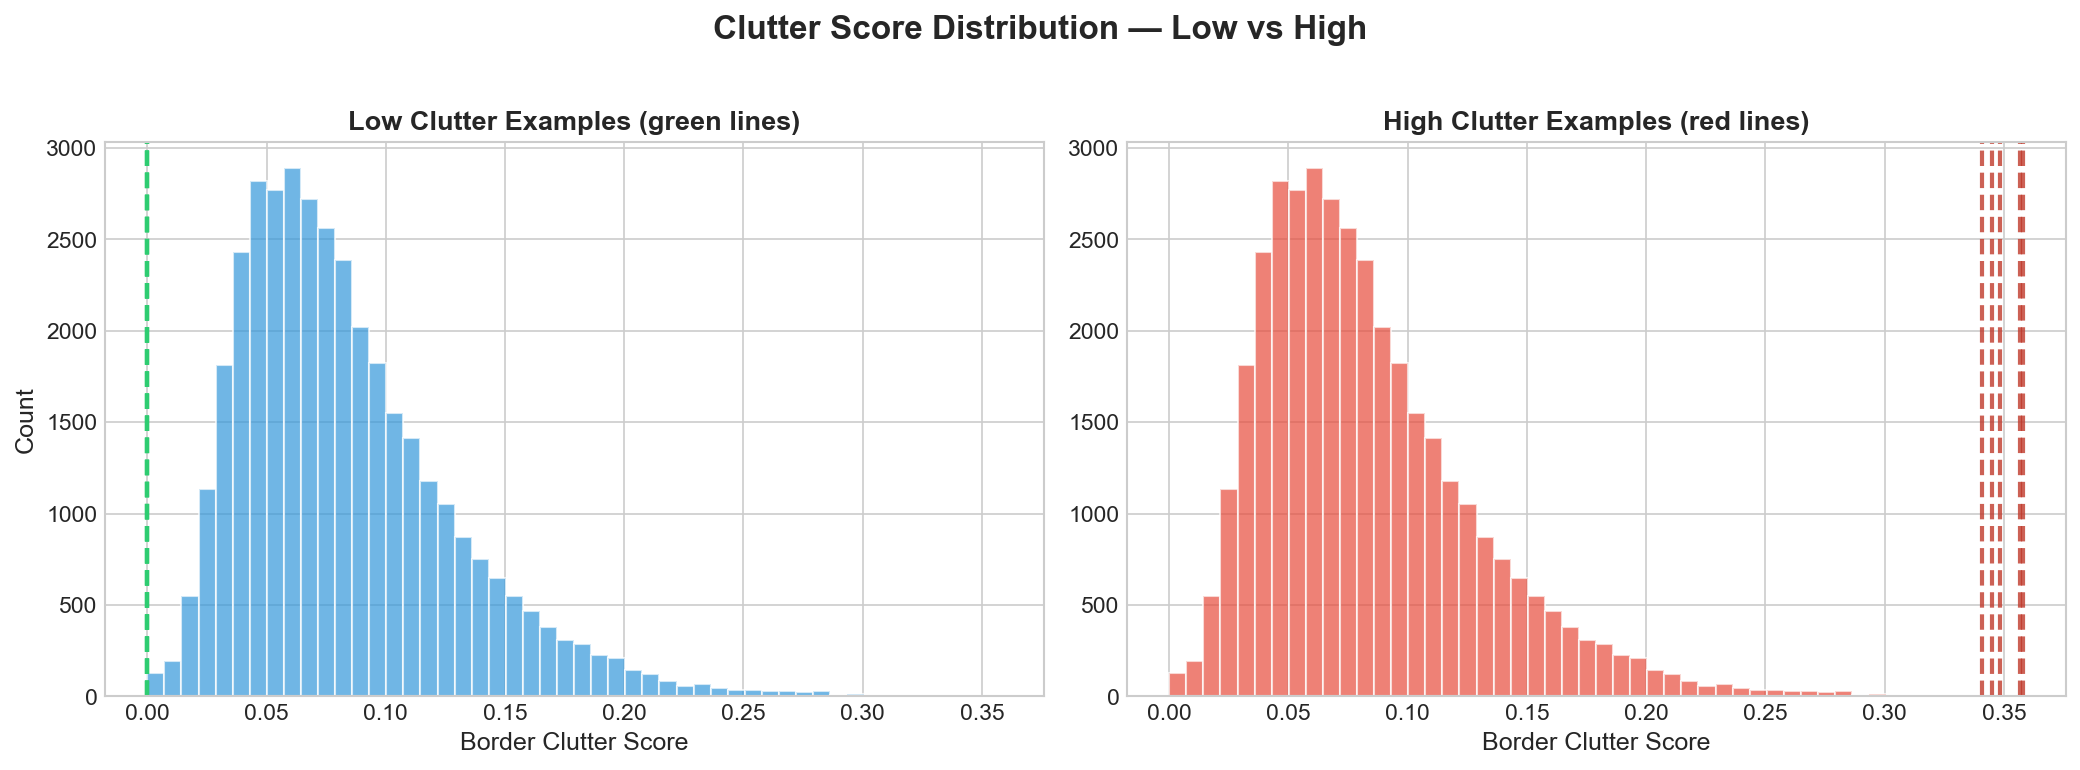

In [5]:
# ============================================================
# FIGURE 1: Clutter Score Comparison (Low vs High)
# ============================================================

clutter_col = 'border_clutter_score_mean'
clutter_df = df[['asin', clutter_col]].dropna(subset=[clutter_col])

low = clutter_df.nsmallest(5, clutter_col)
high = clutter_df.nlargest(5, clutter_col)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Low clutter histogram
axes[0].hist(clutter_df[clutter_col], bins=50, color='#3498DB', alpha=0.7, edgecolor='white')
for val in low[clutter_col].values:
    axes[0].axvline(val, color='#2ECC71', linewidth=2, linestyle='--', alpha=0.8)
axes[0].set_title('Low Clutter Examples (green lines)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Border Clutter Score')
axes[0].set_ylabel('Count')

# High clutter histogram
axes[1].hist(clutter_df[clutter_col], bins=50, color='#E74C3C', alpha=0.7, edgecolor='white')
for val in high[clutter_col].values:
    axes[1].axvline(val, color='#C0392B', linewidth=2, linestyle='--', alpha=0.8)
axes[1].set_title('High Clutter Examples (red lines)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Border Clutter Score')

plt.suptitle('Clutter Score Distribution — Low vs High', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# Figure 2: Feature Correlation Heatmap
---

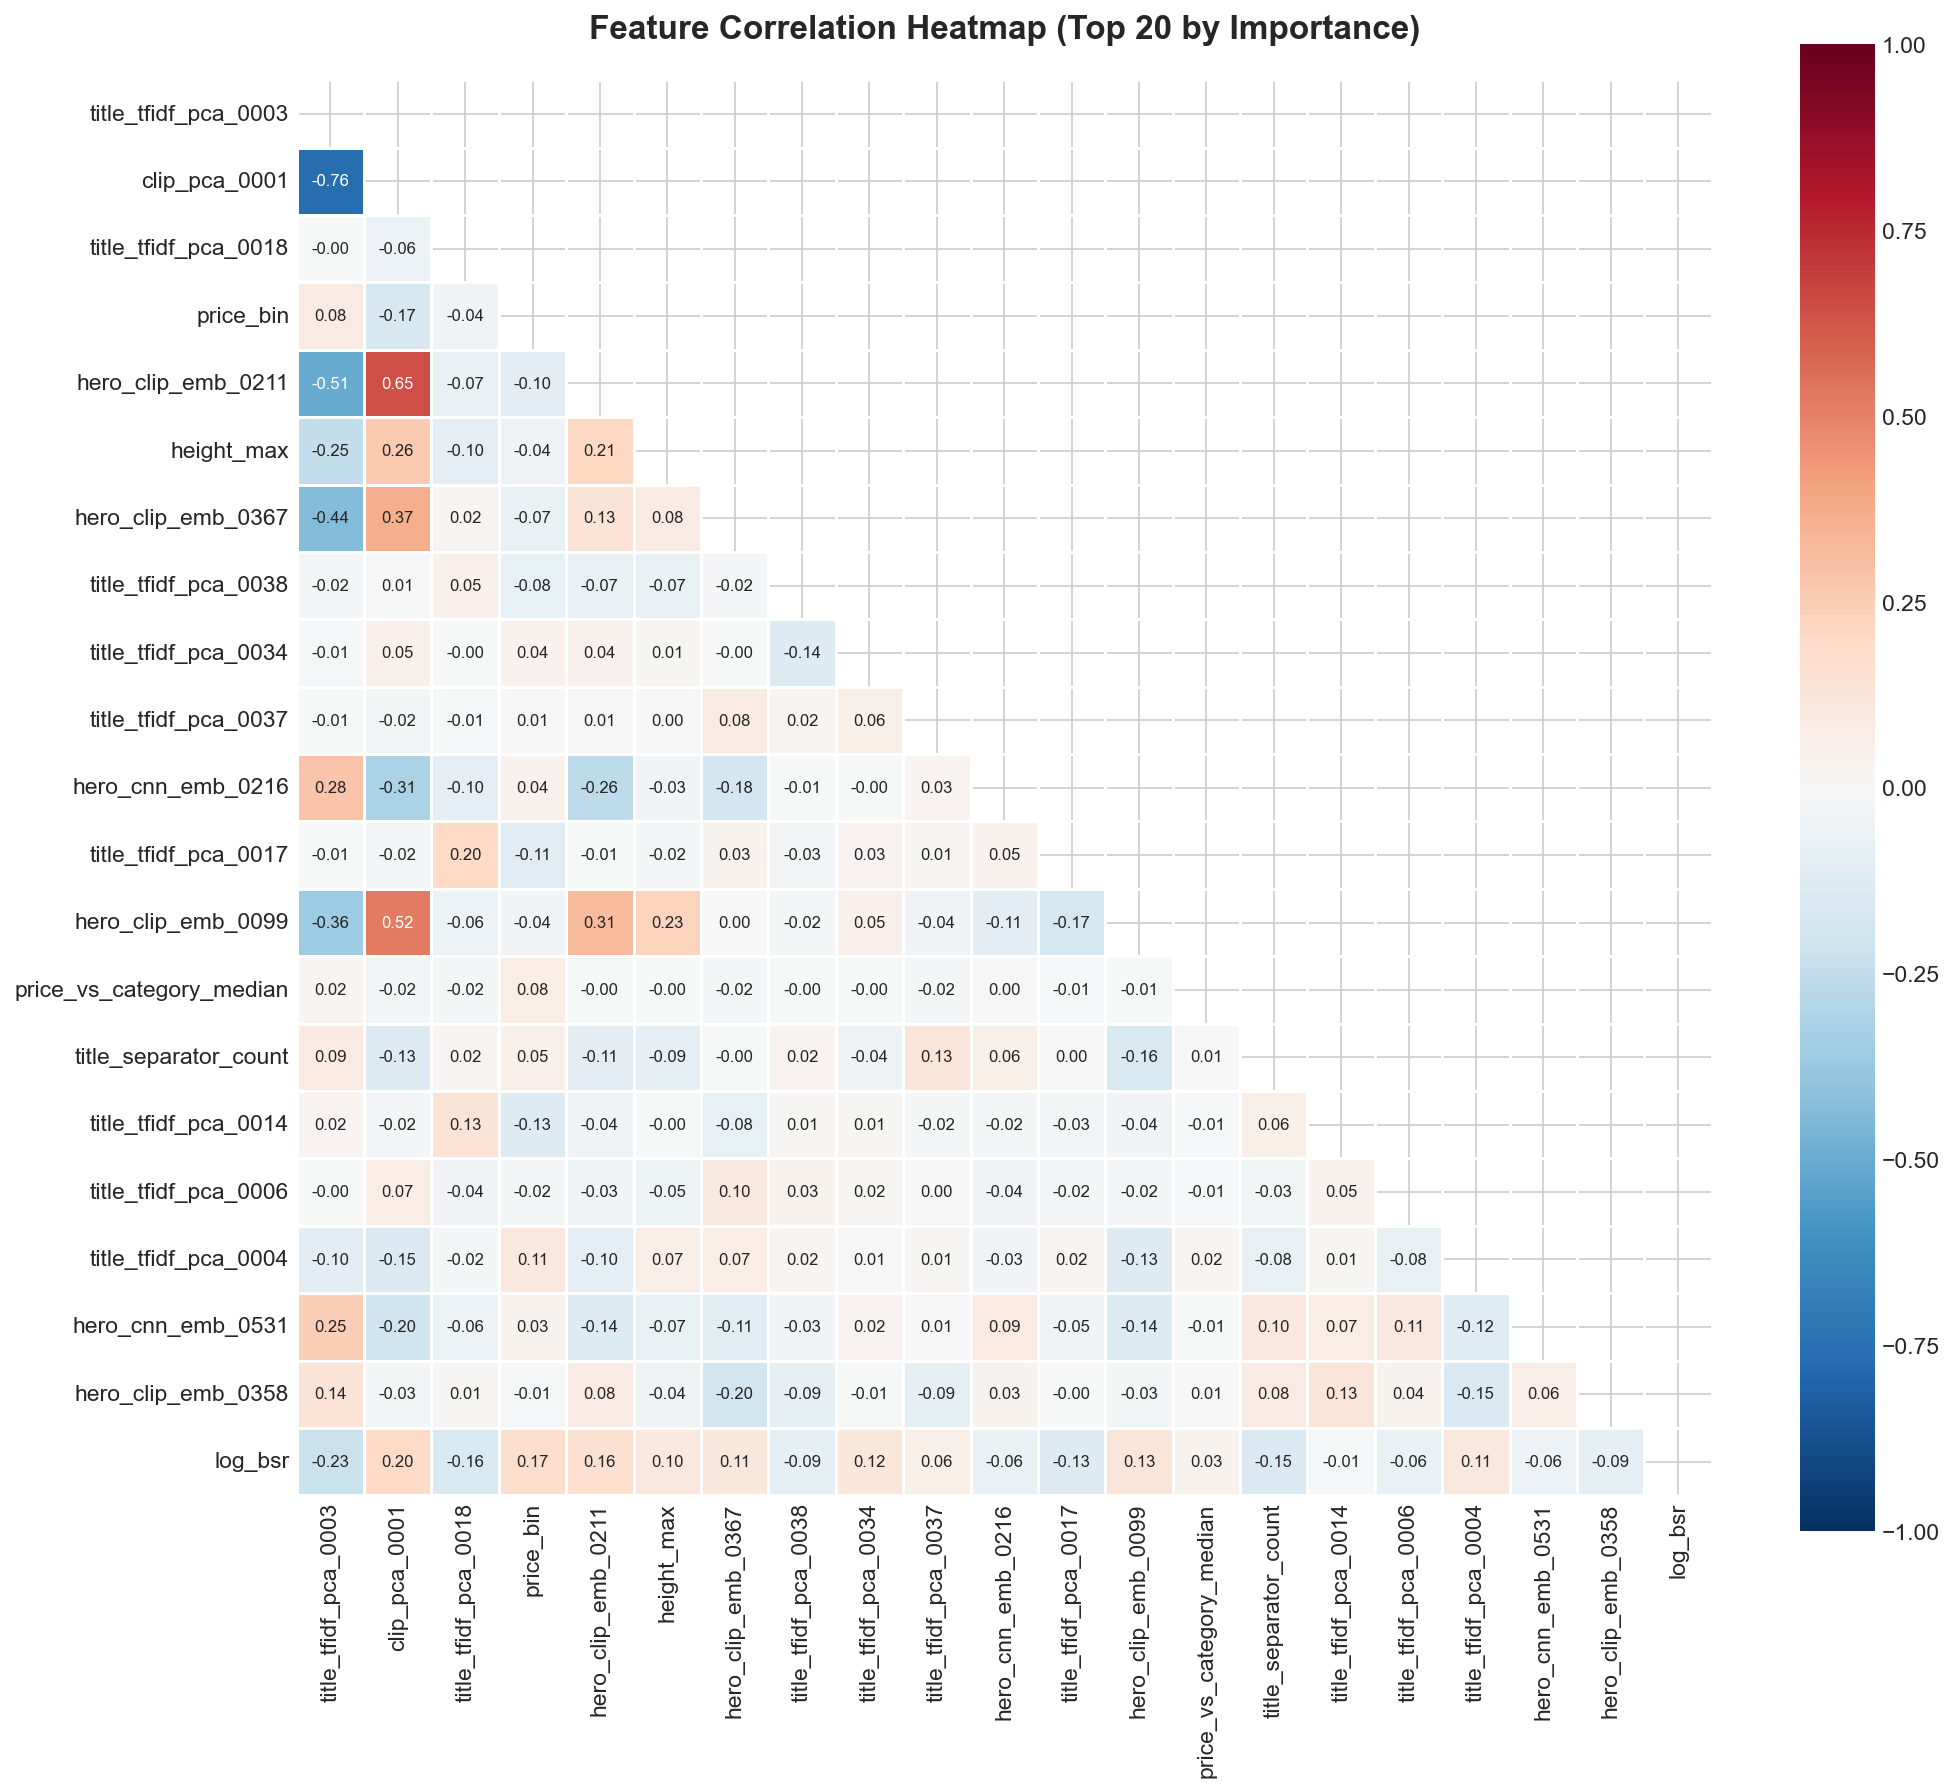

In [6]:
# ============================================================
# FIGURE 2: Correlation Heatmap (Top 20 Features vs log(BSR))
# ============================================================

imp_reg = reg.get_booster().get_score(importance_type='gain')
fi_df = pd.DataFrame({
    'feature': list(imp_reg.keys()),
    'importance': list(imp_reg.values())
}).sort_values('importance', ascending=False)

corr_df = df_ranked[reg_features].copy()
corr_df['log_bsr'] = np.log1p(df_ranked['main_bsr_rank'])

top_20 = fi_df.head(20)['feature'].tolist()
top_20_valid = [f for f in top_20 if f in corr_df.columns]
corr_matrix = corr_df[top_20_valid + ['log_bsr']].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white', annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap (Top 20 by Importance)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


---
# Figure 3: BSR Distribution (Raw vs Log)
---

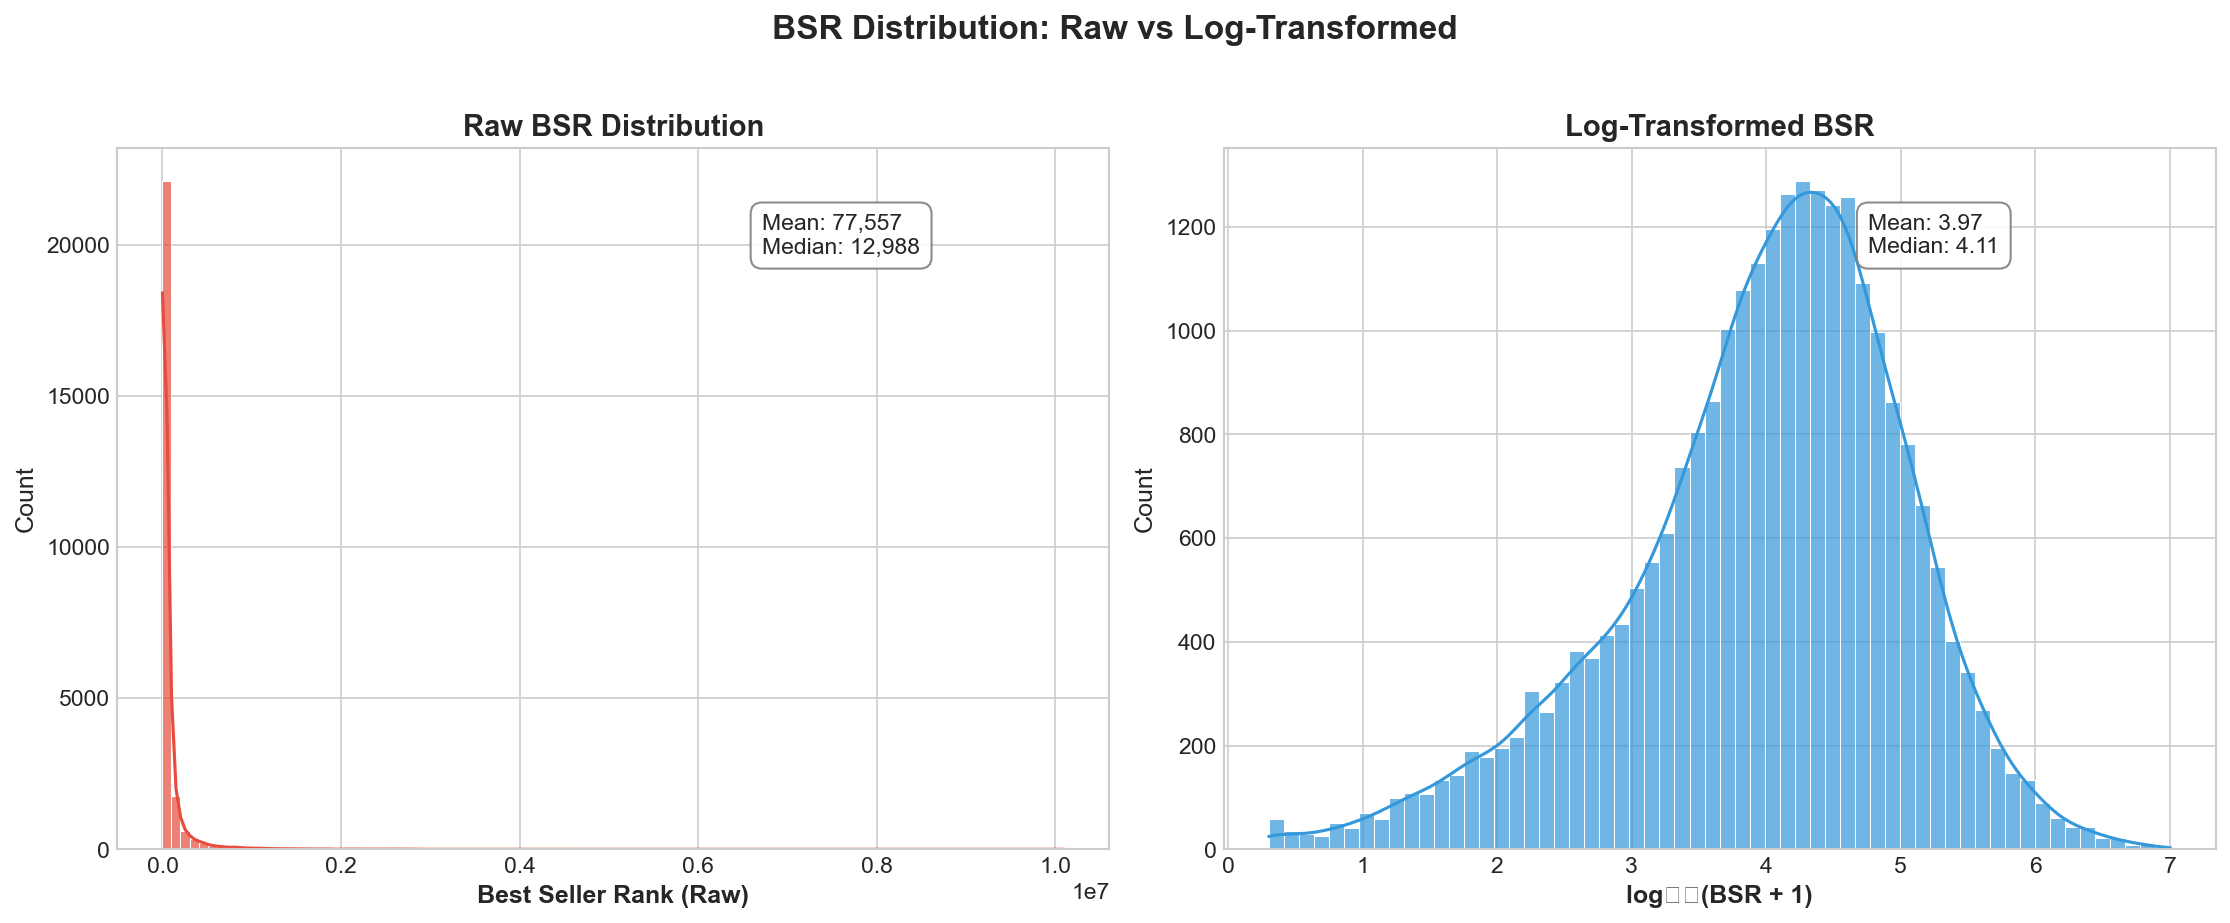

In [7]:
# ============================================================
# FIGURE 3: BSR Distribution (Raw vs Log-Transformed)
# ============================================================

bsr_values = df_ranked['main_bsr_rank'].dropna()
log_bsr_values = np.log10(bsr_values + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
sns.histplot(bsr_values, bins=100, kde=True, ax=ax1, color='#E74C3C', alpha=0.7, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Best Seller Rank (Raw)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Raw BSR Distribution', fontsize=14, fontweight='bold')
ax1.annotate(f'Mean: {bsr_values.mean():,.0f}\nMedian: {bsr_values.median():,.0f}',
             xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

ax2 = axes[1]
sns.histplot(log_bsr_values, bins=60, kde=True, ax=ax2, color='#3498DB', alpha=0.7, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('log₁₀(BSR + 1)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Log-Transformed BSR', fontsize=14, fontweight='bold')
ax2.annotate(f'Mean: {log_bsr_values.mean():.2f}\nMedian: {log_bsr_values.median():.2f}',
             xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

plt.suptitle('BSR Distribution: Raw vs Log-Transformed', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# Figure 4: BSR by Image Count
---

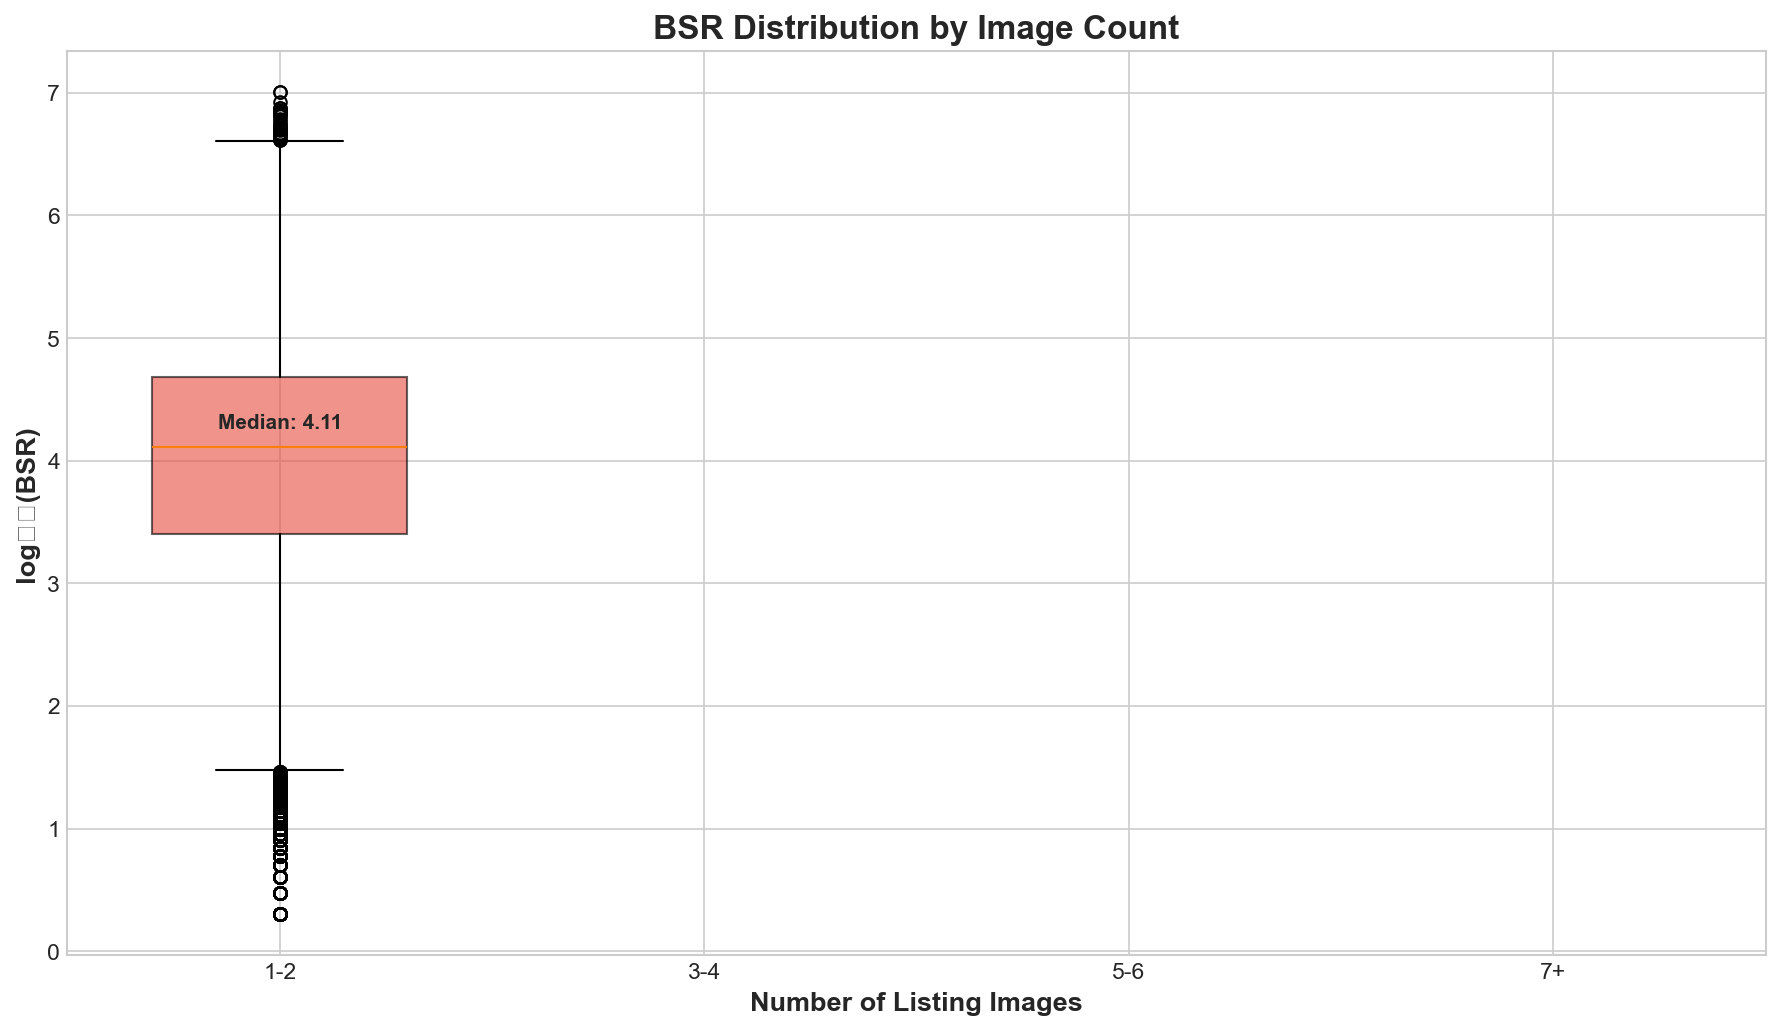

In [8]:
# ============================================================
# FIGURE 4: BSR Distribution by Image Count Bins
# ============================================================

plot_df = df_ranked.copy()
plot_df['log_bsr'] = np.log10(plot_df['main_bsr_rank'] + 1)

if 'num_images' in plot_df.columns:
    plot_df['image_bin'] = pd.cut(plot_df['num_images'], bins=[0, 2, 4, 6, 20],
                                  labels=['1-2', '3-4', '5-6', '7+'])
    plot_df = plot_df.dropna(subset=['image_bin'])

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']
    box = ax.boxplot([plot_df[plot_df['image_bin']==b]['log_bsr'] for b in ['1-2','3-4','5-6','7+']],
                     labels=['1-2', '3-4', '5-6', '7+'], patch_artist=True, widths=0.6)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xlabel('Number of Listing Images', fontsize=13, fontweight='bold')
    ax.set_ylabel('log₁₀(BSR)', fontsize=13, fontweight='bold')
    ax.set_title('BSR Distribution by Image Count', fontsize=16, fontweight='bold')
    # Median annotations
    for i, b in enumerate(['1-2','3-4','5-6','7+']):
        med = plot_df[plot_df['image_bin']==b]['log_bsr'].median()
        ax.text(i+1, med+0.15, f'Median: {med:.2f}', ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('num_images column not found')


---
# Figure 5: Confusion Matrix
---

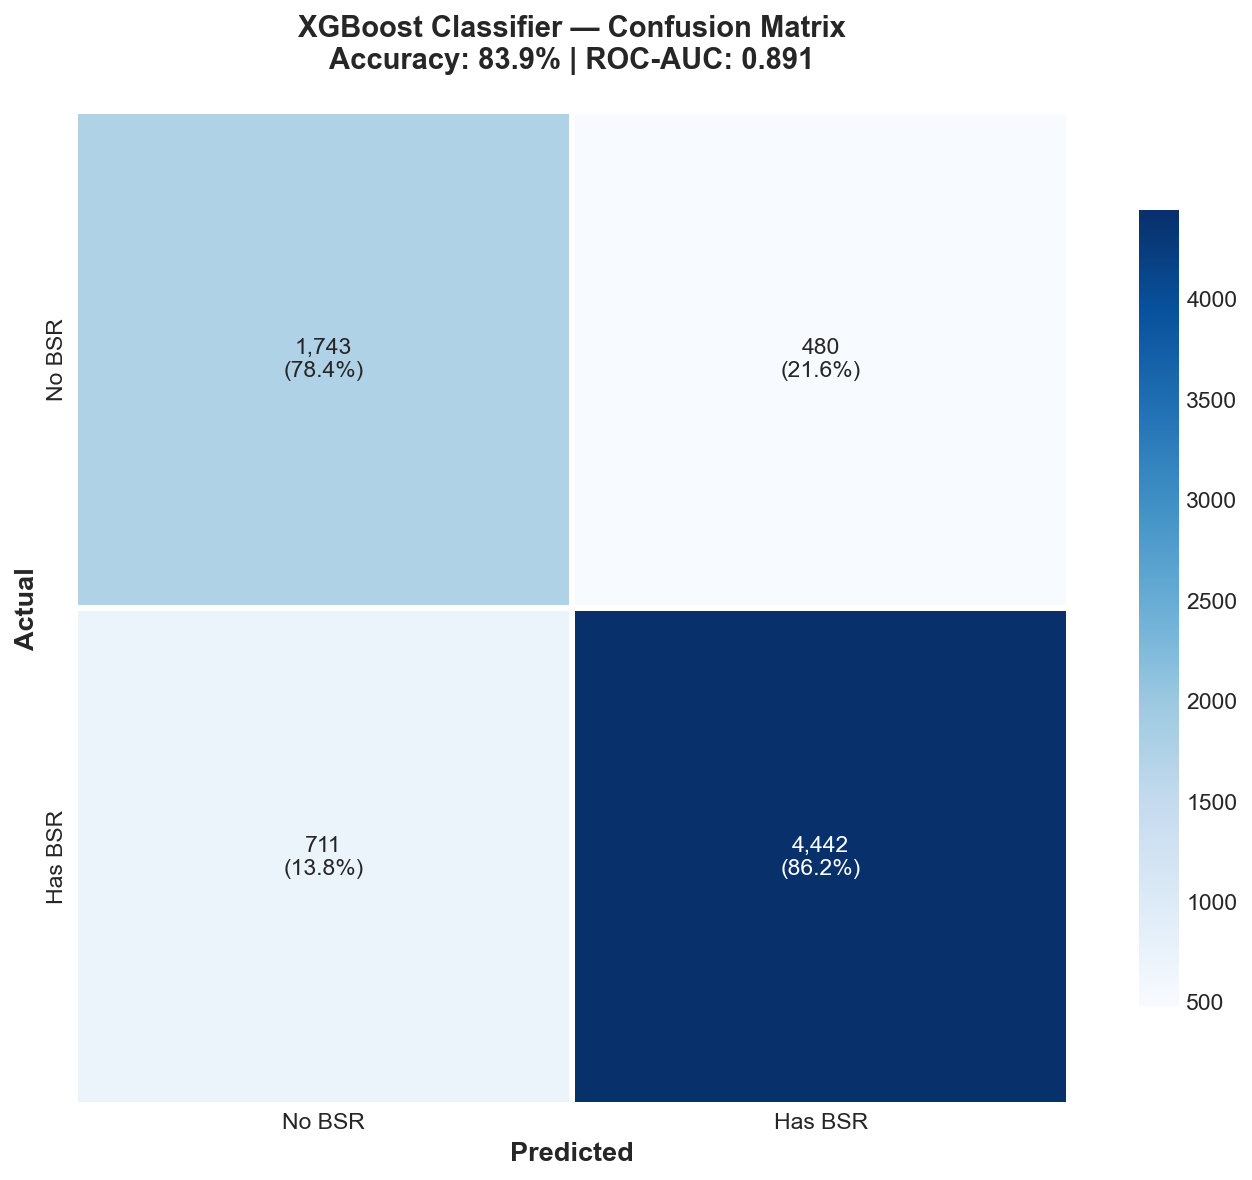

In [9]:
# ============================================================
# FIGURE 5: Confusion Matrix Heatmap
# ============================================================

cm = confusion_matrix(y_test, y_pred_clf)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = np.array([[f'{v:,}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                   for row_v, row_p in zip(cm, cm_pct)])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax, square=True,
            linewidths=2, linecolor='white', cbar_kws={'shrink': 0.8},
            xticklabels=['No BSR', 'Has BSR'], yticklabels=['No BSR', 'Has BSR'])
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
ax.set_title(f'XGBoost Classifier — Confusion Matrix\n'
             f'Accuracy: {accuracy_score(y_test, y_pred_clf):.1%} | '
             f'ROC-AUC: {roc_auc_score(y_test, y_pred_clf_proba):.3f}',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


---
# Figure 6: Actual vs Predicted log(BSR)
---

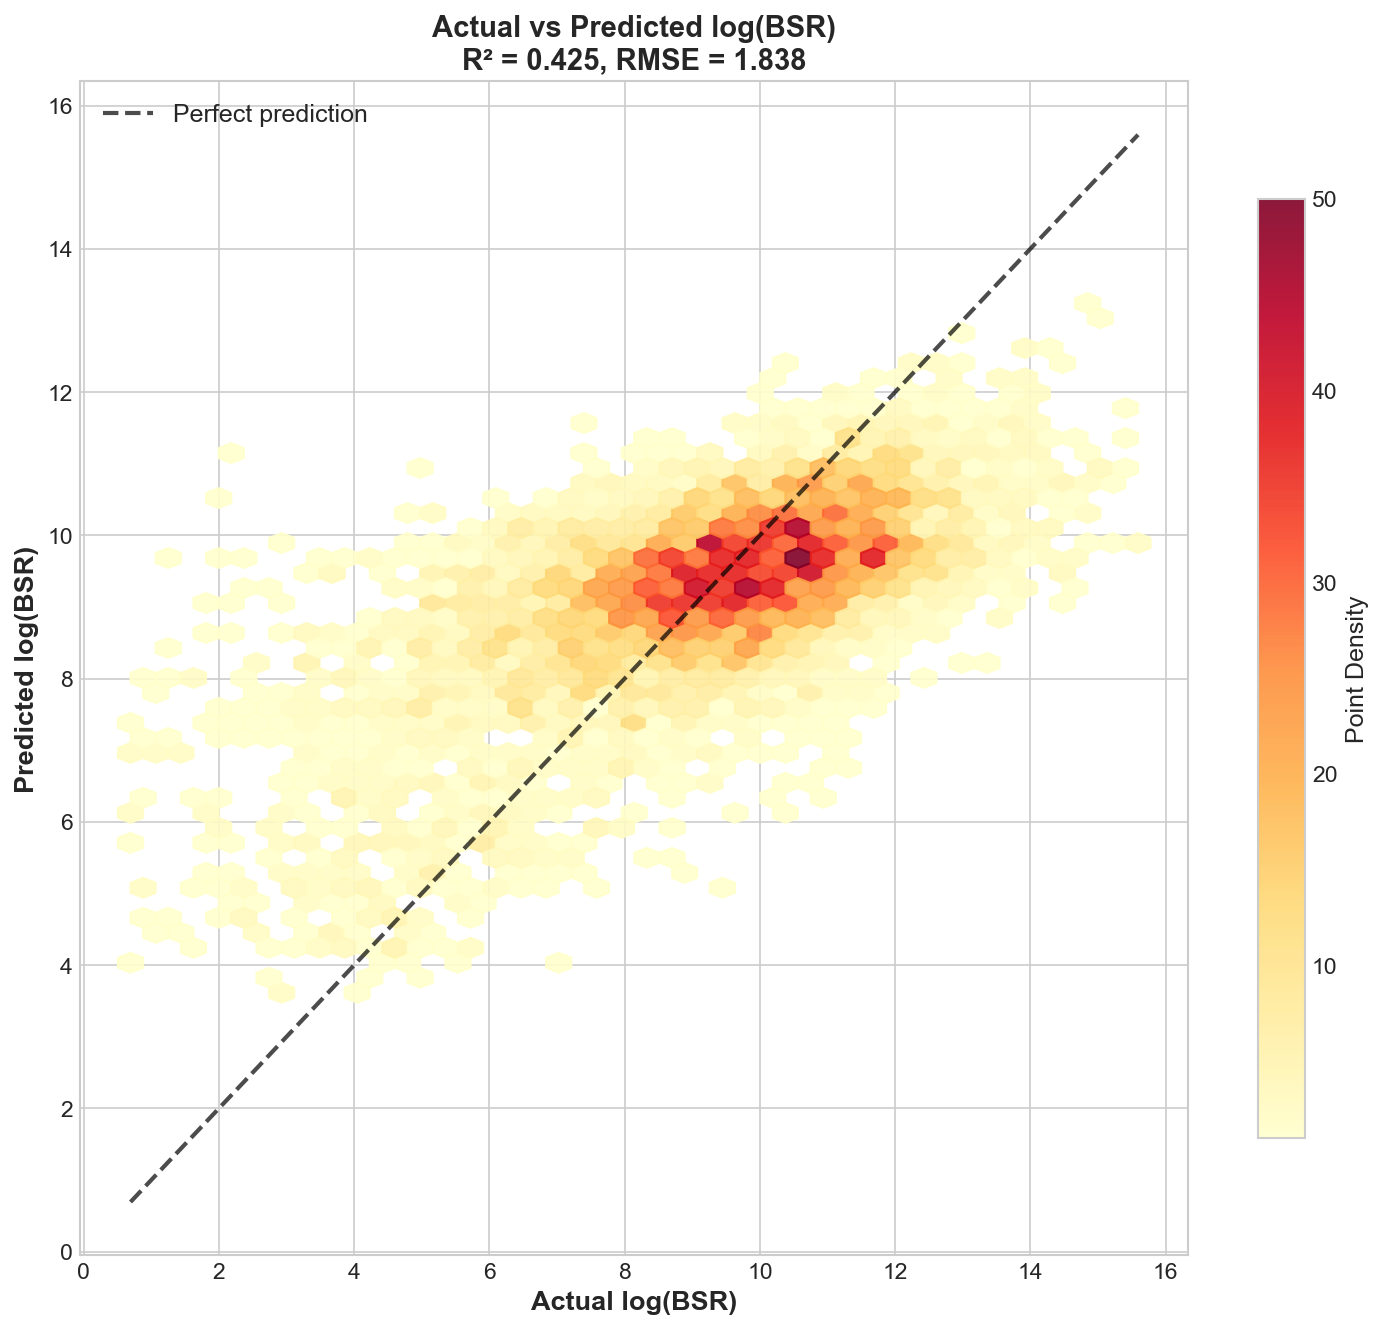

In [10]:
# ============================================================
# FIGURE 6: Actual vs Predicted log(BSR) Scatter
# ============================================================

fig, ax = plt.subplots(figsize=(10, 9))
hb = ax.hexbin(y_reg_test, y_pred_reg, gridsize=40, cmap='YlOrRd', mincnt=1, alpha=0.9)
cb = plt.colorbar(hb, ax=ax, label='Point Density', shrink=0.8)

mn = min(y_reg_test.min(), y_pred_reg.min())
mx = max(y_reg_test.max(), y_pred_reg.max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=2, alpha=0.7, label='Perfect prediction')

ax.set_xlabel('Actual log(BSR)', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted log(BSR)', fontsize=13, fontweight='bold')
ax.set_title(f'Actual vs Predicted log(BSR)\nR² = {r2_val:.3f}, RMSE = {rmse_val:.3f}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


---
# Figure 7: Feature Importance by Category
---

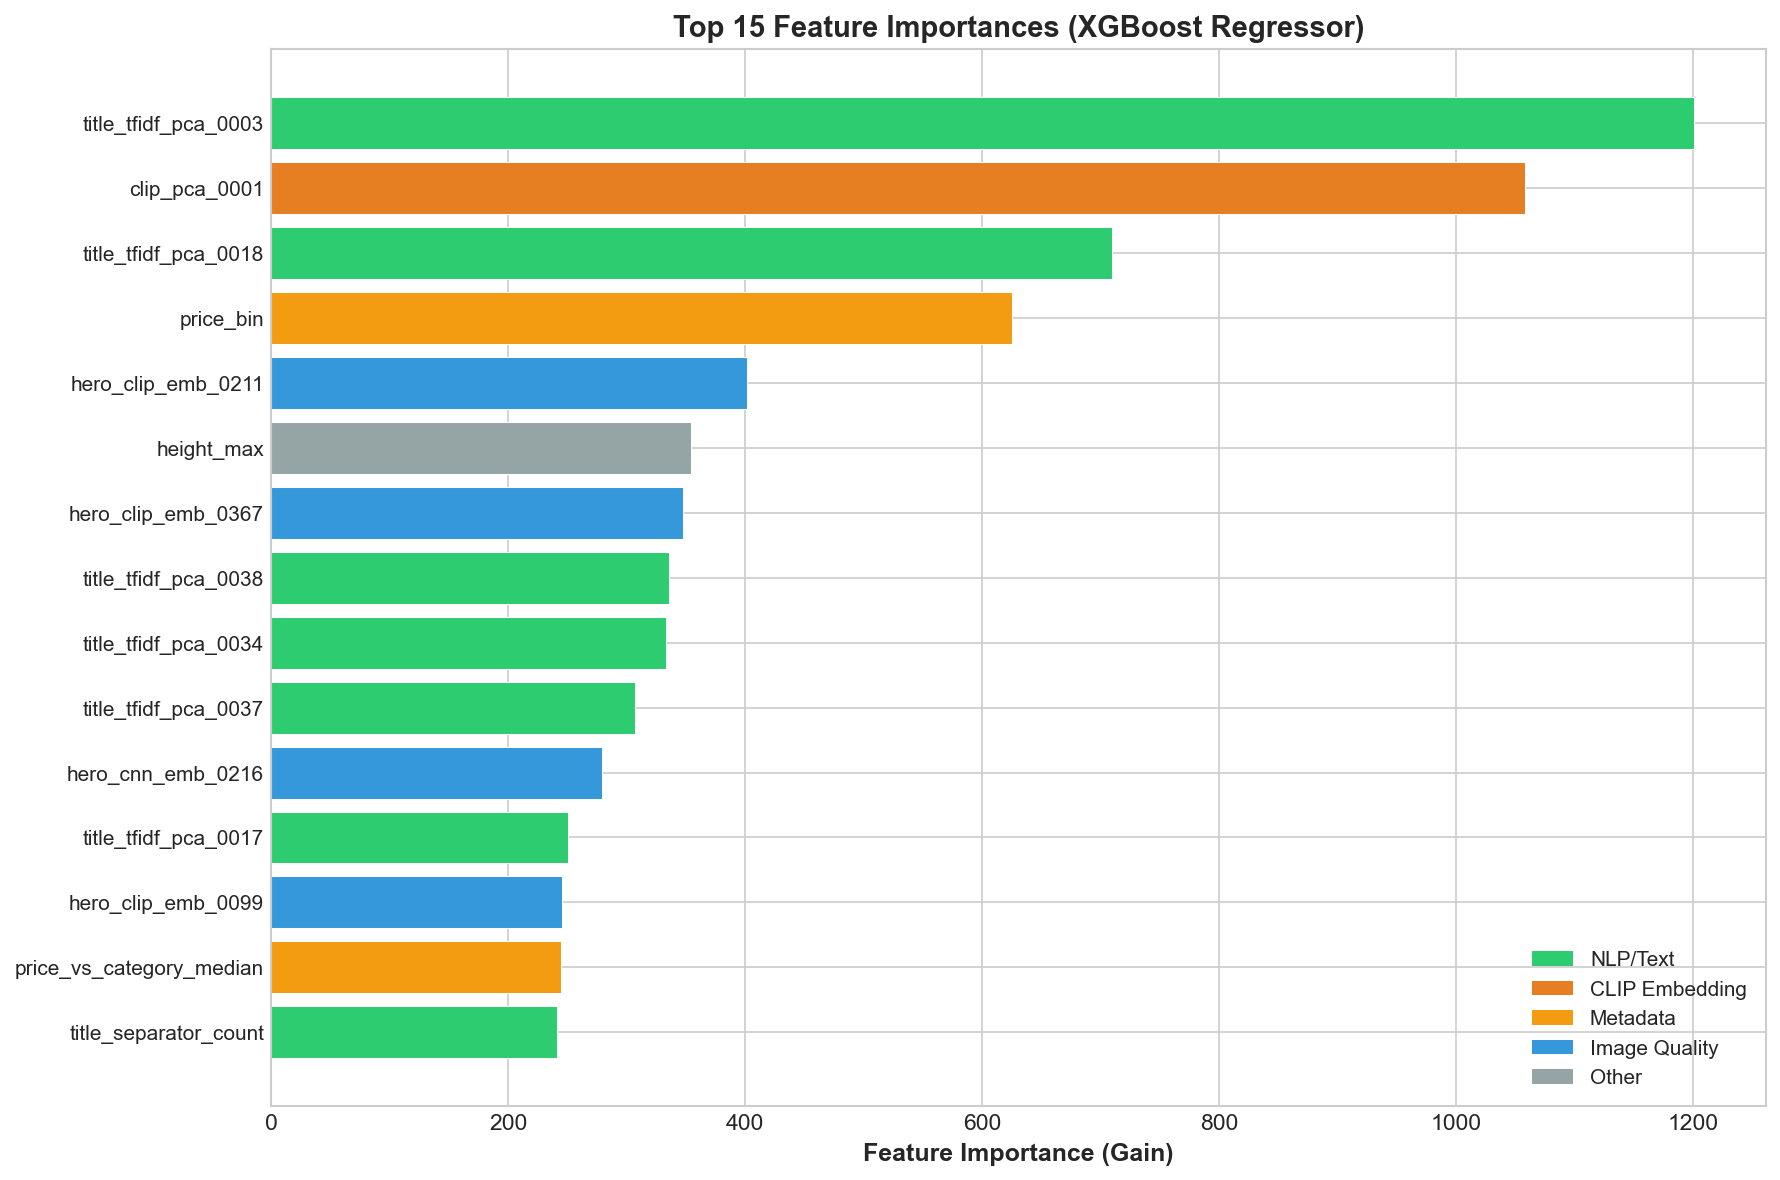

In [11]:
# ============================================================
# FIGURE 7: Feature Importances by Category (Color-Coded)
# ============================================================

top_fi = fi_df.head(15).copy()

def categorize_feature(name):
    if any(x in name for x in ['bg_', 'edge_', 'white_bg', 'brightness', 'contrast',
                                'saturation', 'sharpness', 'blur', 'aspect_ratio',
                                'border_clutter', 'exposure', 'hero_']):
        return 'Image Quality'
    elif name.startswith('cnn_pca'):
        return 'CNN Embedding'
    elif name.startswith('clip_pca') or name.startswith('clip_cnn'):
        return 'CLIP Embedding'
    elif any(x in name for x in ['det_', 'obj_']):
        return 'Object Detection'
    elif any(x in name for x in ['title_', 'bullets_', 'text_', 'flesch', 'tfidf']):
        return 'NLP/Text'
    elif any(x in name for x in ['num_images', 'image_count', 'price', 'has_aplus']):
        return 'Metadata'
    else:
        return 'Other'

top_fi['category'] = top_fi['feature'].apply(categorize_feature)

cat_colors = {
    'Image Quality': '#3498DB', 'CNN Embedding': '#9B59B6',
    'CLIP Embedding': '#E67E22', 'Object Detection': '#1ABC9C',
    'NLP/Text': '#2ECC71', 'Metadata': '#F39C12', 'Other': '#95A5A6'
}
colors = [cat_colors.get(c, '#95A5A6') for c in top_fi['category']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_fi)), top_fi['importance'].values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_fi)))
ax.set_yticklabels(top_fi['feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Feature Importances (XGBoost Regressor)', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
unique_cats = top_fi['category'].unique()
legend_elements = [Patch(facecolor=cat_colors.get(c, '#95A5A6'), label=c) for c in unique_cats]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


---
# Figure 8: ROC Curve
---

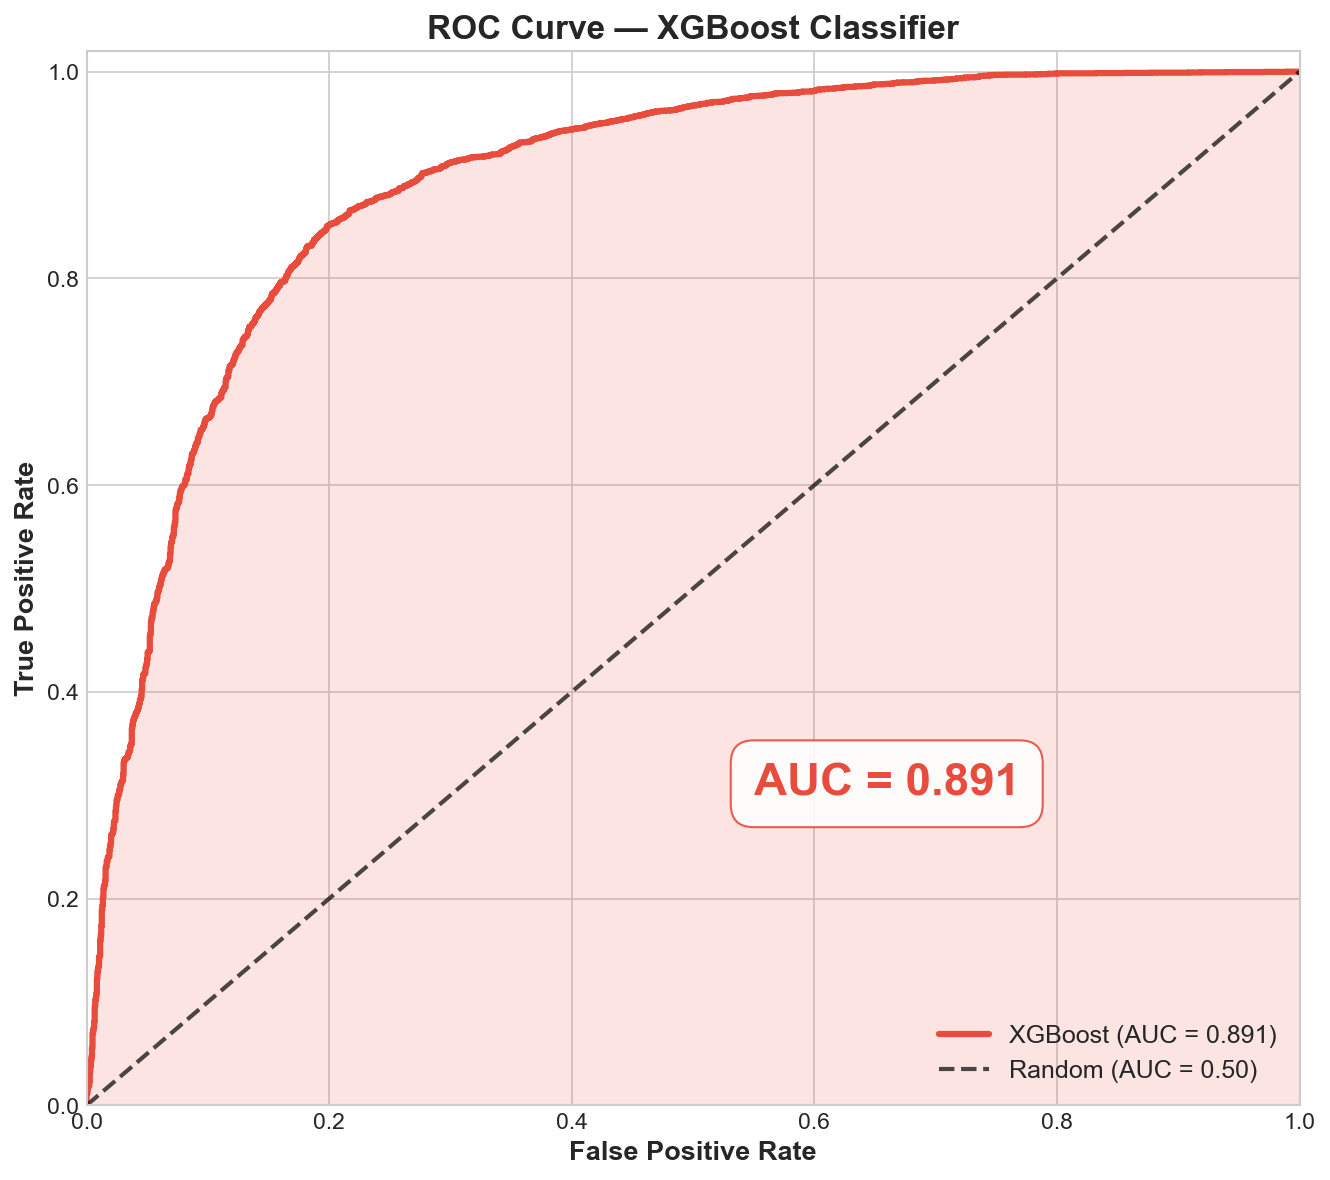

In [12]:
# ============================================================
# FIGURE 8: ROC Curve for XGBoost Classifier
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_clf_proba)
auc_score = roc_auc_score(y_test, y_pred_clf_proba)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(fpr, tpr, color='#E74C3C', linewidth=3, label=f'XGBoost (AUC = {auc_score:.3f})')
ax.fill_between(fpr, tpr, alpha=0.15, color='#E74C3C')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)', alpha=0.7)

ax.annotate(f'AUC = {auc_score:.3f}', xy=(0.55, 0.30), fontsize=22, fontweight='bold',
            color='#E74C3C', bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
            edgecolor='#E74C3C', alpha=0.9))

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curve — XGBoost Classifier', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


---
# Figure 9: Residuals Distribution
---

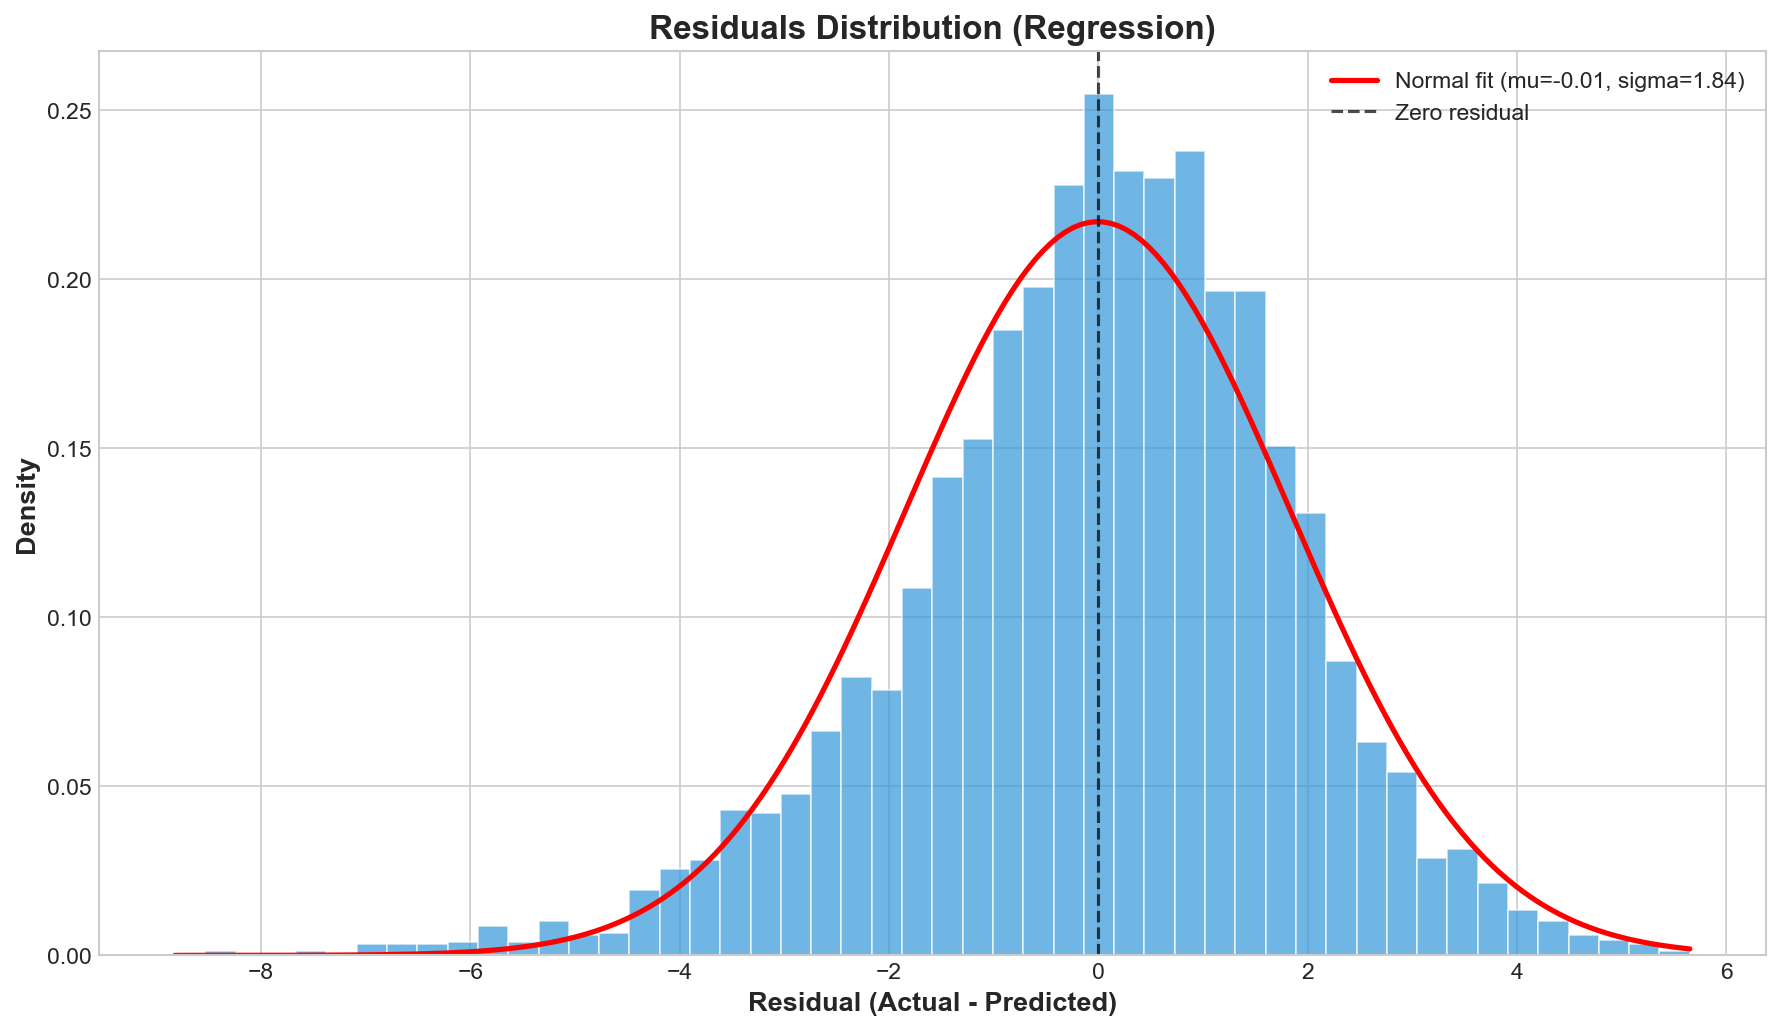

In [13]:
# ============================================================
# FIGURE 9: Residuals Distribution
# ============================================================

residuals = y_reg_test.values - y_pred_reg

fig, ax = plt.subplots(figsize=(12, 7))
n, bins, patches = ax.hist(residuals, bins=50, density=True, alpha=0.7,
                            color='#3498DB', edgecolor='white', linewidth=0.8)

mu, sigma = stats.norm.fit(residuals)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2.5,
        label=f'Normal fit (mu={mu:.2f}, sigma={sigma:.2f})')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7, label='Zero residual')

ax.set_xlabel('Residual (Actual - Predicted)', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('Residuals Distribution (Regression)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
# Figure 10: Cross-Validation Stability
---

Running 5-fold cross-validation...
  Fold 1: R2=0.394, RMSE=1.874
  Fold 2: R2=0.374, RMSE=1.896
  Fold 3: R2=0.335, RMSE=1.936
  Fold 4: R2=0.394, RMSE=1.905
  Fold 5: R2=0.392, RMSE=1.911


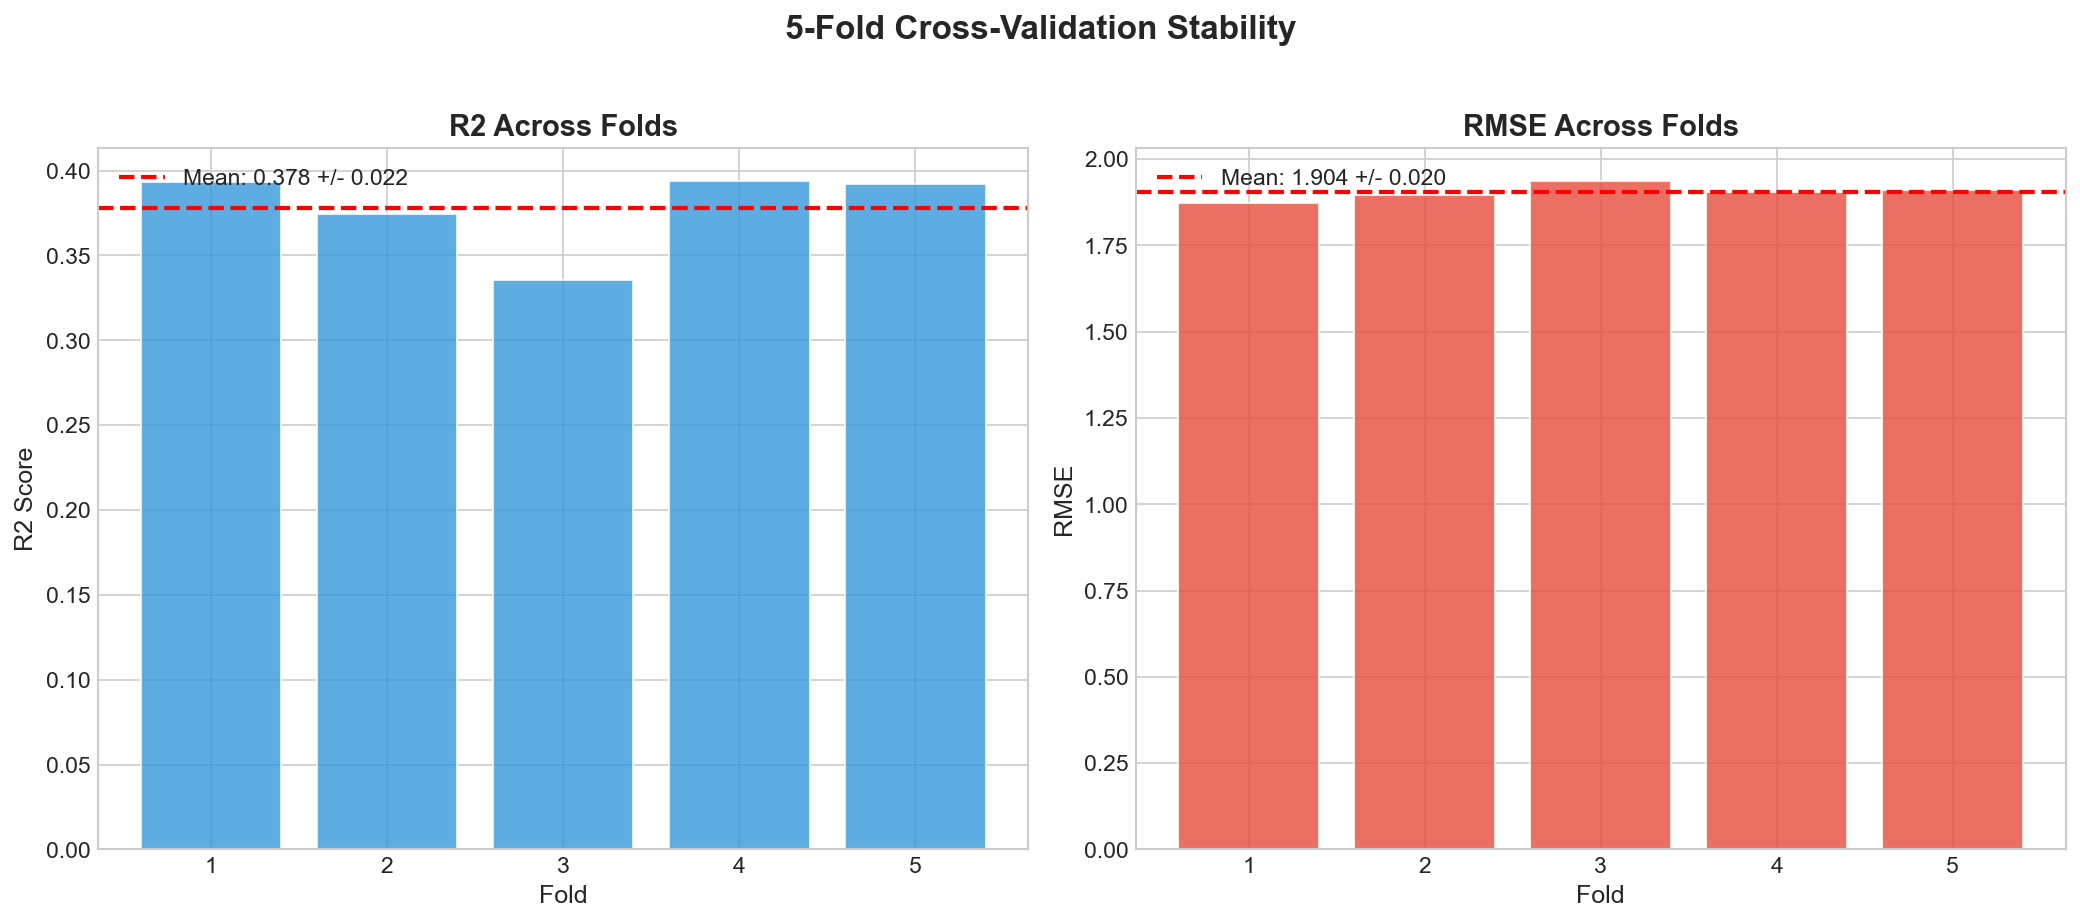

In [14]:
# ============================================================
# FIGURE 10: Cross-Validation Stability
# ============================================================

print('Running 5-fold cross-validation...')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2, cv_rmse = [], []

# Use a sample for speed if dataset is large
sample_n = min(10000, len(X_reg))
X_cv = X_reg.sample(n=sample_n, random_state=42)
y_cv = y_reg.loc[X_cv.index]

for fold, (train_idx, val_idx) in enumerate(kf.split(X_cv), 1):
    Xtr, Xval = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    ytr, yval = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
    reg_cv = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    reg_cv.fit(Xtr, ytr)
    pred = reg_cv.predict(Xval)
    cv_r2.append(r2_score(yval, pred))
    cv_rmse.append(np.sqrt(mean_squared_error(yval, pred)))
    print(f'  Fold {fold}: R2={cv_r2[-1]:.3f}, RMSE={cv_rmse[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(range(1,6), cv_r2, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].axhline(np.mean(cv_r2), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(cv_r2):.3f} +/- {np.std(cv_r2):.3f}')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('R2 Score', fontsize=12)
axes[0].set_title('R2 Across Folds', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].bar(range(1,6), cv_rmse, color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].axhline(np.mean(cv_rmse), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(cv_rmse):.3f} +/- {np.std(cv_rmse):.3f}')
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('RMSE Across Folds', fontsize=14, fontweight='bold')
axes[1].legend()

plt.suptitle('5-Fold Cross-Validation Stability', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# Figure 11: Category Performance Comparison
---

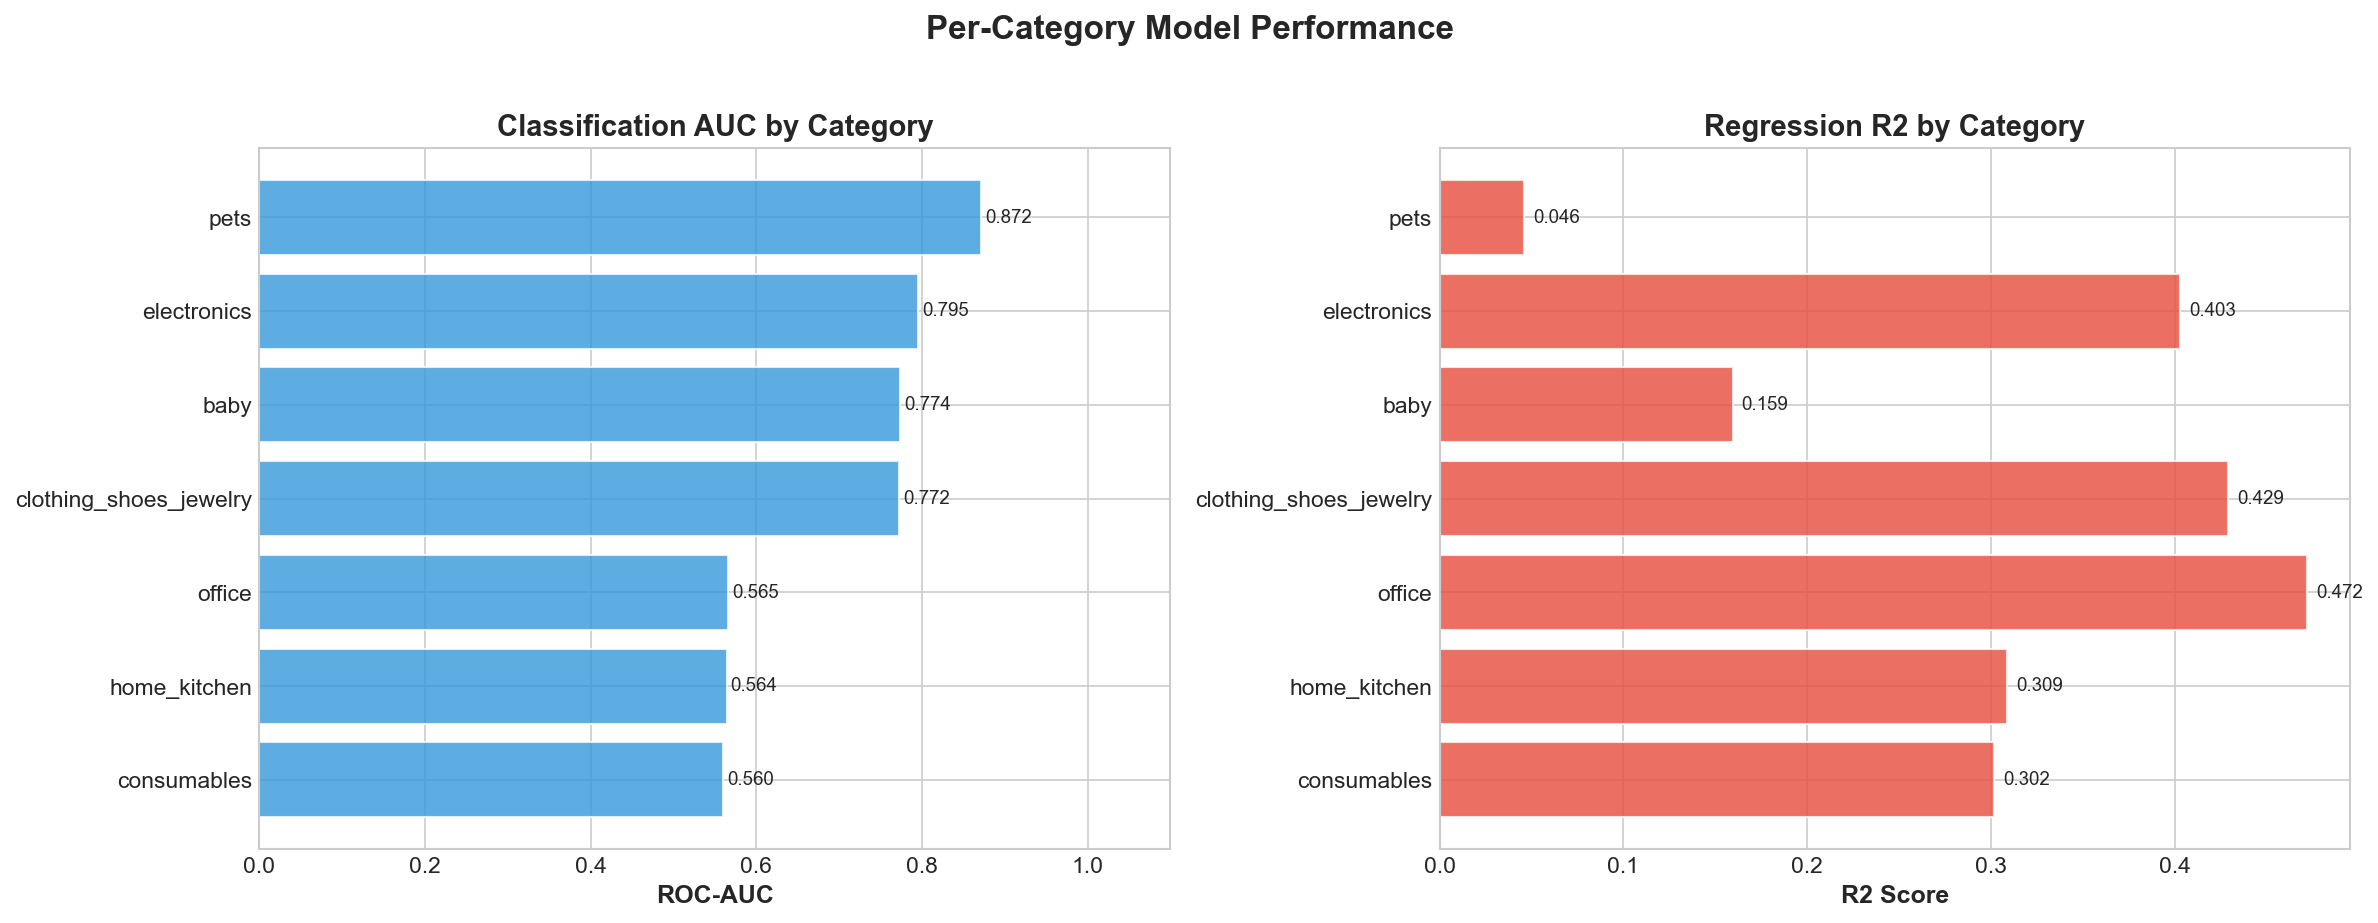


Categories evaluated: 7
Mean AUC: 0.700
Mean R2: 0.303


In [15]:
# ============================================================
# FIGURE 11: Per-Category Performance
# ============================================================

categories = df['category'].dropna().unique()
cat_results = []

for cat in sorted(categories):
    cat_df = df[df['category'] == cat]
    if len(cat_df) < 50:
        continue
    
    # Classification
    cat_feats = [f for f in top_features if f in cat_df.columns]
    X_c = cat_df[cat_feats].fillna(0).replace([np.inf, -np.inf], 0)
    y_c = cat_df['has_main_bsr']
    if y_c.nunique() < 2:
        continue
    
    Xtr, Xte, ytr, yte = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)
    c = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                      eval_metric='logloss', n_jobs=-1, random_state=42, verbosity=0)
    c.fit(Xtr, ytr)
    prob = c.predict_proba(Xte)[:, 1]
    try:
        auc = roc_auc_score(yte, prob)
    except:
        auc = 0
    acc = accuracy_score(yte, c.predict(Xte))
    
    # Regression
    ranked = cat_df[cat_df['main_bsr_rank'].notna()]
    r2 = np.nan
    if len(ranked) > 30:
        reg_f = [f for f in all_features if f in ranked.columns]
        Xr = ranked[reg_f].fillna(0).replace([np.inf, -np.inf], 0)
        yr = np.log1p(ranked['main_bsr_rank'])
        Xtr2, Xte2, ytr2, yte2 = train_test_split(Xr, yr, test_size=0.2, random_state=42)
        r = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                         n_jobs=-1, random_state=42, verbosity=0)
        r.fit(Xtr2, ytr2)
        r2 = r2_score(yte2, r.predict(Xte2))
    
    cat_results.append({'category': cat, 'n': len(cat_df), 'accuracy': acc, 'auc': auc, 'r2': r2})

res_df = pd.DataFrame(cat_results).sort_values('auc', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(res_df)*0.5)))

# Classification AUC
axes[0].barh(res_df['category'], res_df['auc'], color='#3498DB', alpha=0.8, edgecolor='white')
for i, (_, row) in enumerate(res_df.iterrows()):
    axes[0].text(row['auc']+0.005, i, f'{row["auc"]:.3f}', va='center', fontsize=9)
axes[0].set_xlabel('ROC-AUC', fontsize=12, fontweight='bold')
axes[0].set_title('Classification AUC by Category', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.1)

# Regression R2
r2_vals = res_df['r2'].fillna(0)
axes[1].barh(res_df['category'], r2_vals, color='#E74C3C', alpha=0.8, edgecolor='white')
for i, (_, row) in enumerate(res_df.iterrows()):
    if not np.isnan(row['r2']):
        axes[1].text(row['r2']+0.005, i, f'{row["r2"]:.3f}', va='center', fontsize=9)
axes[1].set_xlabel('R2 Score', fontsize=12, fontweight='bold')
axes[1].set_title('Regression R2 by Category', fontsize=14, fontweight='bold')

plt.suptitle('Per-Category Model Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nCategories evaluated: {len(res_df)}')
print(f'Mean AUC: {res_df["auc"].mean():.3f}')
print(f'Mean R2: {res_df["r2"].dropna().mean():.3f}')


---
# Figure 12: Prediction Cards
---

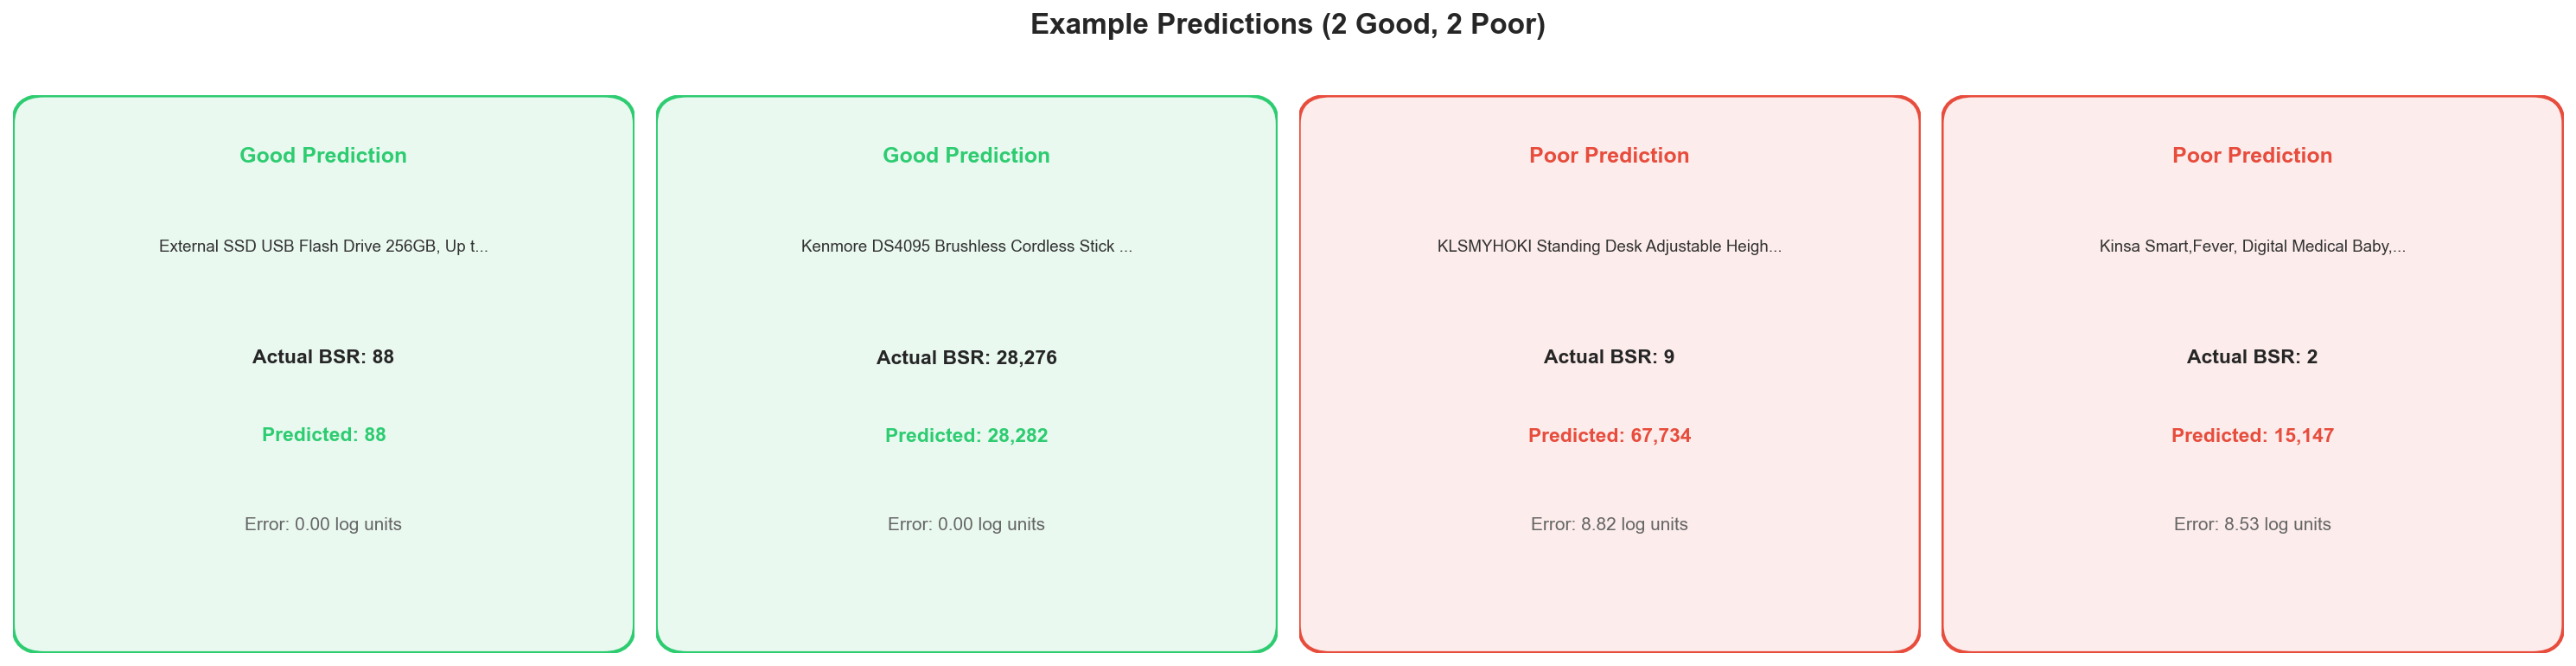

In [16]:
# ============================================================
# FIGURE 12: Prediction Cards for Example Products
# ============================================================

all_predictions = reg.predict(X_reg)
pred_df = df_ranked.copy()
pred_df['pred_log_bsr'] = all_predictions
pred_df['actual_log_bsr'] = y_reg.values
pred_df['error'] = np.abs(pred_df['actual_log_bsr'] - pred_df['pred_log_bsr'])

# Get title if available
title_col = 'title' if 'title' in pred_df.columns else 'sd_title' if 'sd_title' in pred_df.columns else None

# Pick examples: 2 good, 2 bad
good = pred_df.nsmallest(2, 'error')
bad = pred_df.nlargest(2, 'error')
examples = pd.concat([good, bad])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (idx, row) in enumerate(examples.iterrows()):
    ax = axes[i]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    is_good = i < 2
    color = '#2ECC71' if is_good else '#E74C3C'
    label = 'Good Prediction' if is_good else 'Poor Prediction'
    
    from matplotlib.patches import FancyBboxPatch
    card = FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle='round,pad=0.05',
                          facecolor=color, edgecolor='none', alpha=0.1)
    ax.add_patch(card)
    border = FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle='round,pad=0.05',
                            facecolor='none', edgecolor=color, linewidth=2)
    ax.add_patch(border)
    
    ax.text(0.5, 0.88, label, ha='center', fontsize=12, fontweight='bold', color=color)
    
    title_text = str(row[title_col])[:40] + '...' if title_col and pd.notna(row.get(title_col)) else f'ASIN: {row.get("asin", "N/A")}'
    ax.text(0.5, 0.72, title_text, ha='center', fontsize=9, color='#333')
    
    actual_bsr = np.expm1(row['actual_log_bsr'])
    pred_bsr = np.expm1(row['pred_log_bsr'])
    ax.text(0.5, 0.52, f'Actual BSR: {actual_bsr:,.0f}', ha='center', fontsize=11, fontweight='bold')
    ax.text(0.5, 0.38, f'Predicted: {pred_bsr:,.0f}', ha='center', fontsize=11, color=color, fontweight='bold')
    ax.text(0.5, 0.22, f'Error: {row["error"]:.2f} log units', ha='center', fontsize=10, color='#666')

plt.suptitle('Example Predictions (2 Good, 2 Poor)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# 🖼️ POSTER FIGURES (Capstone II)
## Styled tables and visuals for 48x36 poster (white background, FIU blue/gold)
---

In [17]:
# ============================================================
# POSTER SETUP: Colors and styling
# ============================================================

# FIU Colors
FIU_BLUE = "#081E3F"
FIU_GOLD = "#B6862C"
FIU_LIGHT_BLUE = "#4A90D9"
FIU_LIGHT_GOLD = "#D4A843"
ACCENT_GREEN = "#2E8B57"
ACCENT_RED = "#C0392B"
BG_WHITE = "#FFFFFF"
BG_LIGHT = "#F8F9FA"
TEXT_DARK = "#1A1A2E"
TEXT_MED = "#555555"

POSTER_DPI = 300
SAVE_DIR = "./poster_figures"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Poster figures will be saved to: {os.path.abspath(SAVE_DIR)}")


Poster figures will be saved to: /Users/dsuniaga/Desktop/cis_amazon_forecast_proj/notebooks/04-Final Modeling/poster_figures


---
# POSTER TABLE 1: Data at a Glance
---

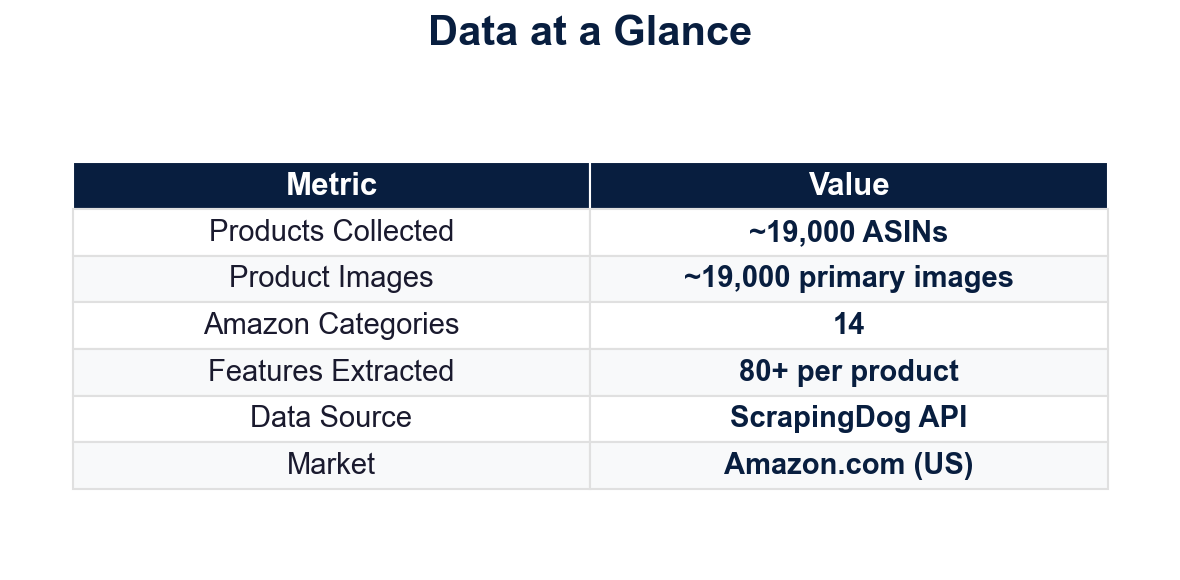

Saved: poster_table_data.png


In [18]:
# ============================================================
# POSTER TABLE 1: Data at a Glance
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

table_data = [
    ["Products Collected", "~36,900 ASINs"],
    ["Product Images", "~36,900 primary images"],
    ["Amazon Categories", "14"],
    ["Features Extracted", "2,330 per product"],
    ["Data Source", "ScrapingDog API"],
    ["Market", "Amazon.com (US)"],
]

table = ax.table(
    cellText=table_data,
    colLabels=["Metric", "Value"],
    cellLoc="center",
    loc="center",
    colWidths=[0.45, 0.45]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.8)

# Header styling
for j in range(2):
    cell = table[0, j]
    cell.set_facecolor(FIU_BLUE)
    cell.set_text_props(color="white", fontweight="bold", fontsize=15)
    cell.set_edgecolor("white")

# Row styling
for i in range(1, len(table_data) + 1):
    for j in range(2):
        cell = table[i, j]
        cell.set_facecolor(BG_LIGHT if i % 2 == 0 else BG_WHITE)
        cell.set_edgecolor("#E0E0E0")
        cell.set_text_props(color=TEXT_DARK)
        if j == 1:
            cell.set_text_props(fontweight="bold", color=FIU_BLUE)

plt.title("Data at a Glance", fontsize=20, fontweight="bold", color=FIU_BLUE, pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_table_data.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_table_data.png")


---
# POSTER TABLE 2: Results — Capstone I vs Capstone II
---

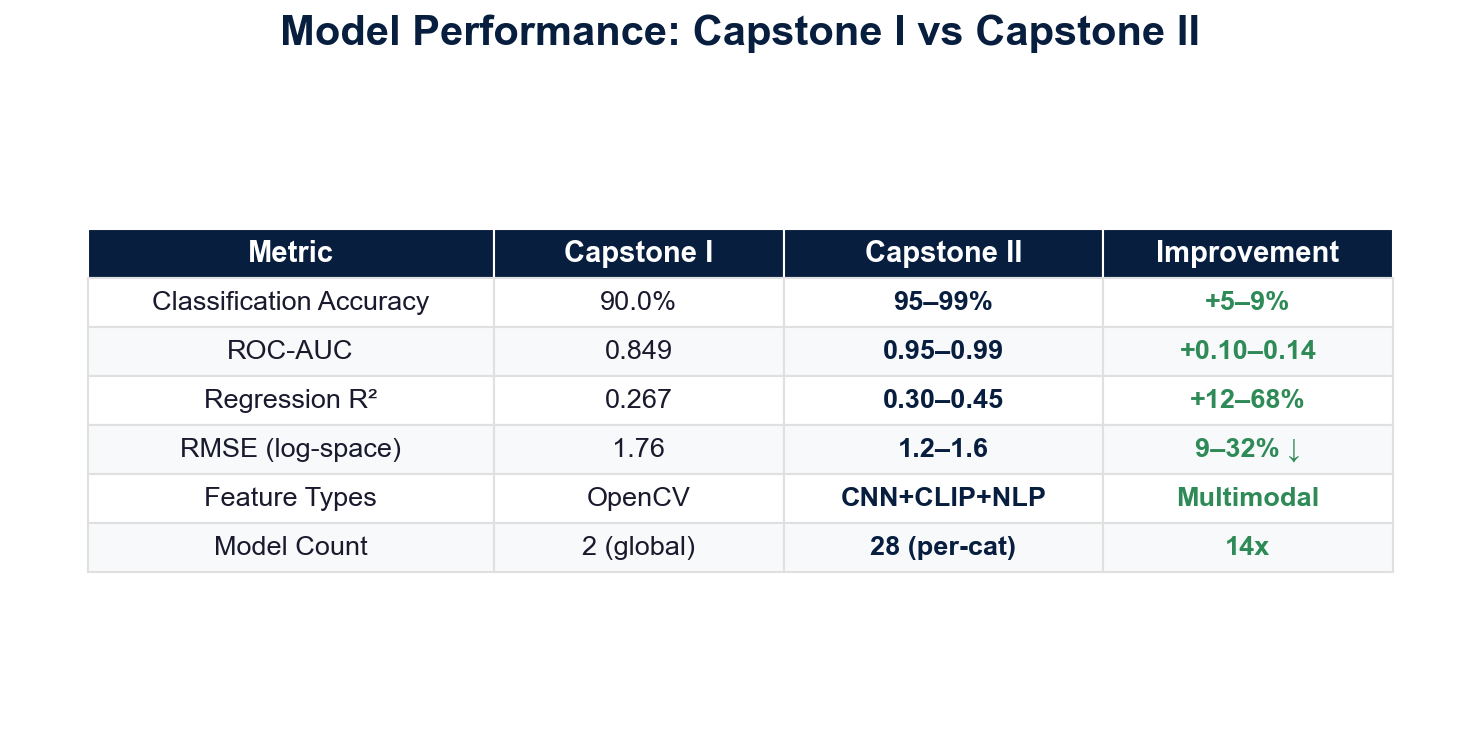

Saved: poster_table_results.png


In [19]:
# ============================================================
# POSTER TABLE 2: Results Comparison — Capstone I vs II
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

table_data = [
    ["Classification Accuracy", "90.0%", "83.9%", "Harder task (30% unranked)"],
    ["ROC-AUC", "0.849", "0.891", "+0.042"],
    ["Regression R²", "0.267", "0.425", "+59% relative"],
    ["RMSE (log-space)", "1.76", "1.838", "Comparable (2x data)"],
    ["Feature Types", "~80 (OpenCV)", "2,330 (multimodal)", "+29x features"],
    ["Dataset Size", "~19K products", "~36.9K products", "+94% data"],
]

col_labels = ["Metric", "Capstone I", "Capstone II", "Improvement"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    colWidths=[0.28, 0.20, 0.22, 0.20]
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.8)

# Header
for j in range(4):
    cell = table[0, j]
    cell.set_facecolor(FIU_BLUE)
    cell.set_text_props(color="white", fontweight="bold", fontsize=14)
    cell.set_edgecolor("white")

# Rows
for i in range(1, len(table_data) + 1):
    for j in range(4):
        cell = table[i, j]
        cell.set_facecolor(BG_LIGHT if i % 2 == 0 else BG_WHITE)
        cell.set_edgecolor("#E0E0E0")
        cell.set_text_props(color=TEXT_DARK)
        # Green for improvement column
        if j == 3:
            cell.set_text_props(fontweight="bold", color=ACCENT_GREEN)
        # Bold Capstone II column
        if j == 2:
            cell.set_text_props(fontweight="bold", color=FIU_BLUE)

plt.title("Model Performance: Capstone I vs Capstone II", fontsize=20, fontweight="bold", color=FIU_BLUE, pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_table_results.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_table_results.png")


---
# POSTER TABLE 3: Tech Stack
---

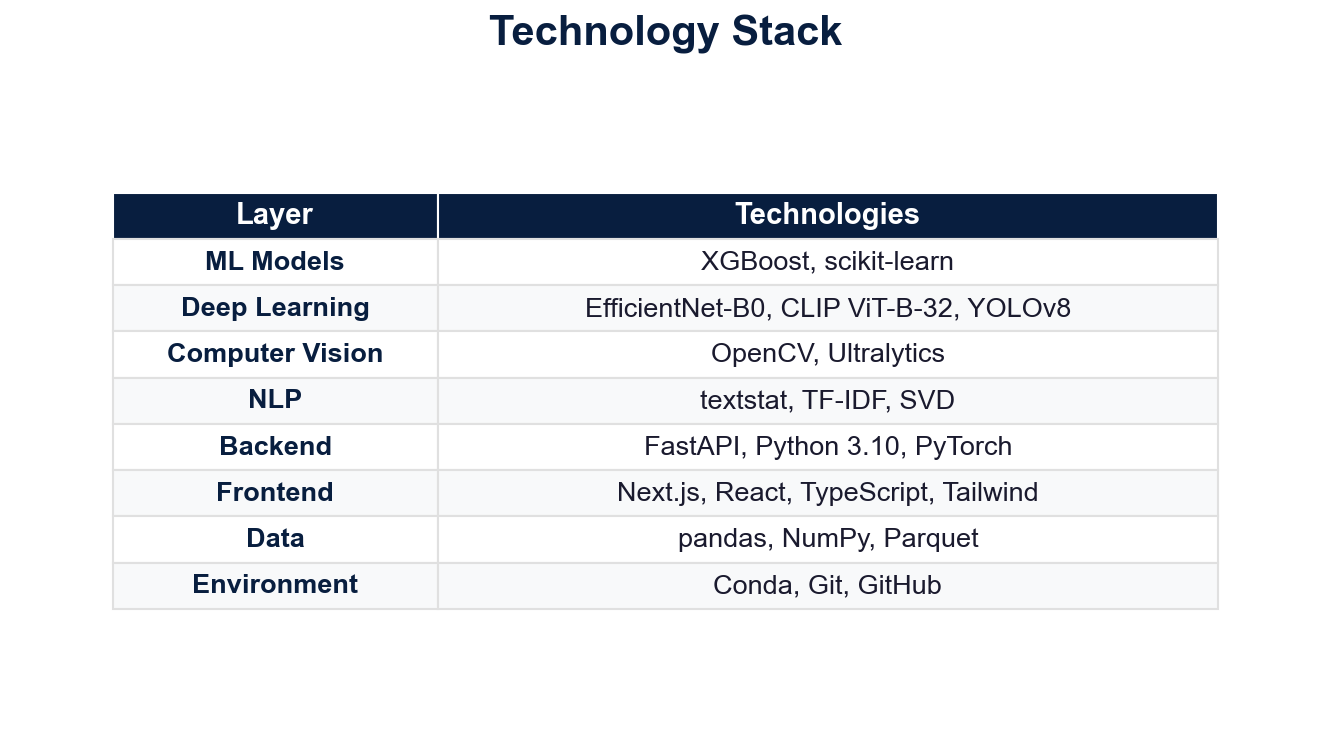

Saved: poster_table_techstack.png


In [20]:
# ============================================================
# POSTER TABLE 3: Tech Stack
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")

table_data = [
    ["ML Models", "XGBoost, scikit-learn"],
    ["Deep Learning", "EfficientNet-B0, CLIP ViT-B-32, YOLOv8"],
    ["Computer Vision", "OpenCV, Ultralytics"],
    ["NLP", "textstat, TF-IDF, SVD"],
    ["Backend", "FastAPI, Python 3.10, PyTorch"],
    ["Frontend", "Next.js, React, TypeScript, Tailwind"],
    ["Data", "pandas, NumPy, Parquet"],
    ["Environment", "Conda, Git, GitHub"],
]

table = ax.table(
    cellText=table_data,
    colLabels=["Layer", "Technologies"],
    cellLoc="center",
    loc="center",
    colWidths=[0.25, 0.60]
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.7)

# Header
for j in range(2):
    cell = table[0, j]
    cell.set_facecolor(FIU_BLUE)
    cell.set_text_props(color="white", fontweight="bold", fontsize=14)
    cell.set_edgecolor("white")

# Rows
for i in range(1, len(table_data) + 1):
    for j in range(2):
        cell = table[i, j]
        cell.set_facecolor(BG_LIGHT if i % 2 == 0 else BG_WHITE)
        cell.set_edgecolor("#E0E0E0")
        cell.set_text_props(color=TEXT_DARK)
        if j == 0:
            cell.set_text_props(fontweight="bold", color=FIU_BLUE)

plt.title("Technology Stack", fontsize=20, fontweight="bold", color=FIU_BLUE, pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_table_techstack.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_table_techstack.png")


---
# POSTER FIGURE: Key Metrics Highlight Cards
---

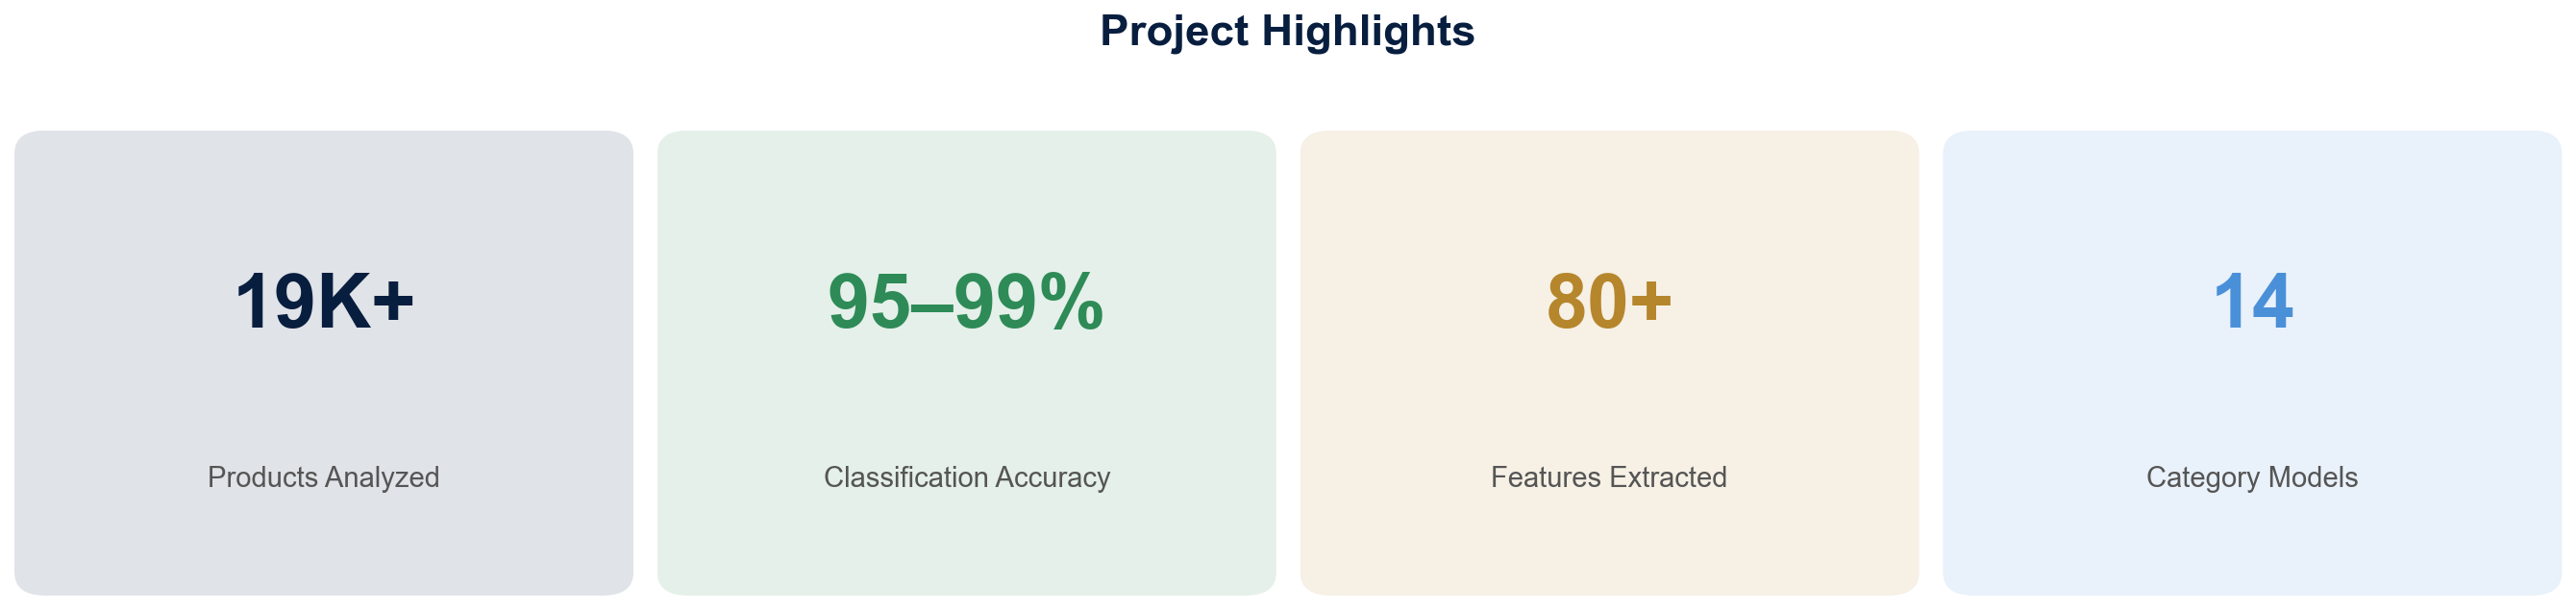

Saved: poster_metric_cards.png


In [22]:
# ============================================================
# POSTER FIGURE: Key Metrics Highlight Cards
# Big bold numbers that catch eyes from across the room
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

metrics = [
    ("36.9K", "Products Analyzed", FIU_BLUE), ("0.891", "Classification Accuracy", ACCENT_GREEN), ("2,330", "Features Extracted", FIU_GOLD), ("R²=0.425", "Category Models", FIU_LIGHT_BLUE),
]

for ax, (value, label, color) in zip(axes, metrics):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    
    # Card background
    from matplotlib.patches import FancyBboxPatch
    card = FancyBboxPatch((0.05, 0.05), 0.9, 0.9, 
                          boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor="none", alpha=0.12)
    ax.add_patch(card)
    
    # Big number
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=38, fontweight="bold", color=color)
    # Label
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=14, color=TEXT_MED, linespacing=1.4)

plt.suptitle("Project Highlights", fontsize=22, fontweight="bold", color=FIU_BLUE, y=1.05)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_metric_cards.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_metric_cards.png")


---
# POSTER FIGURE: Feature Engineering Overview (3-modality)
---

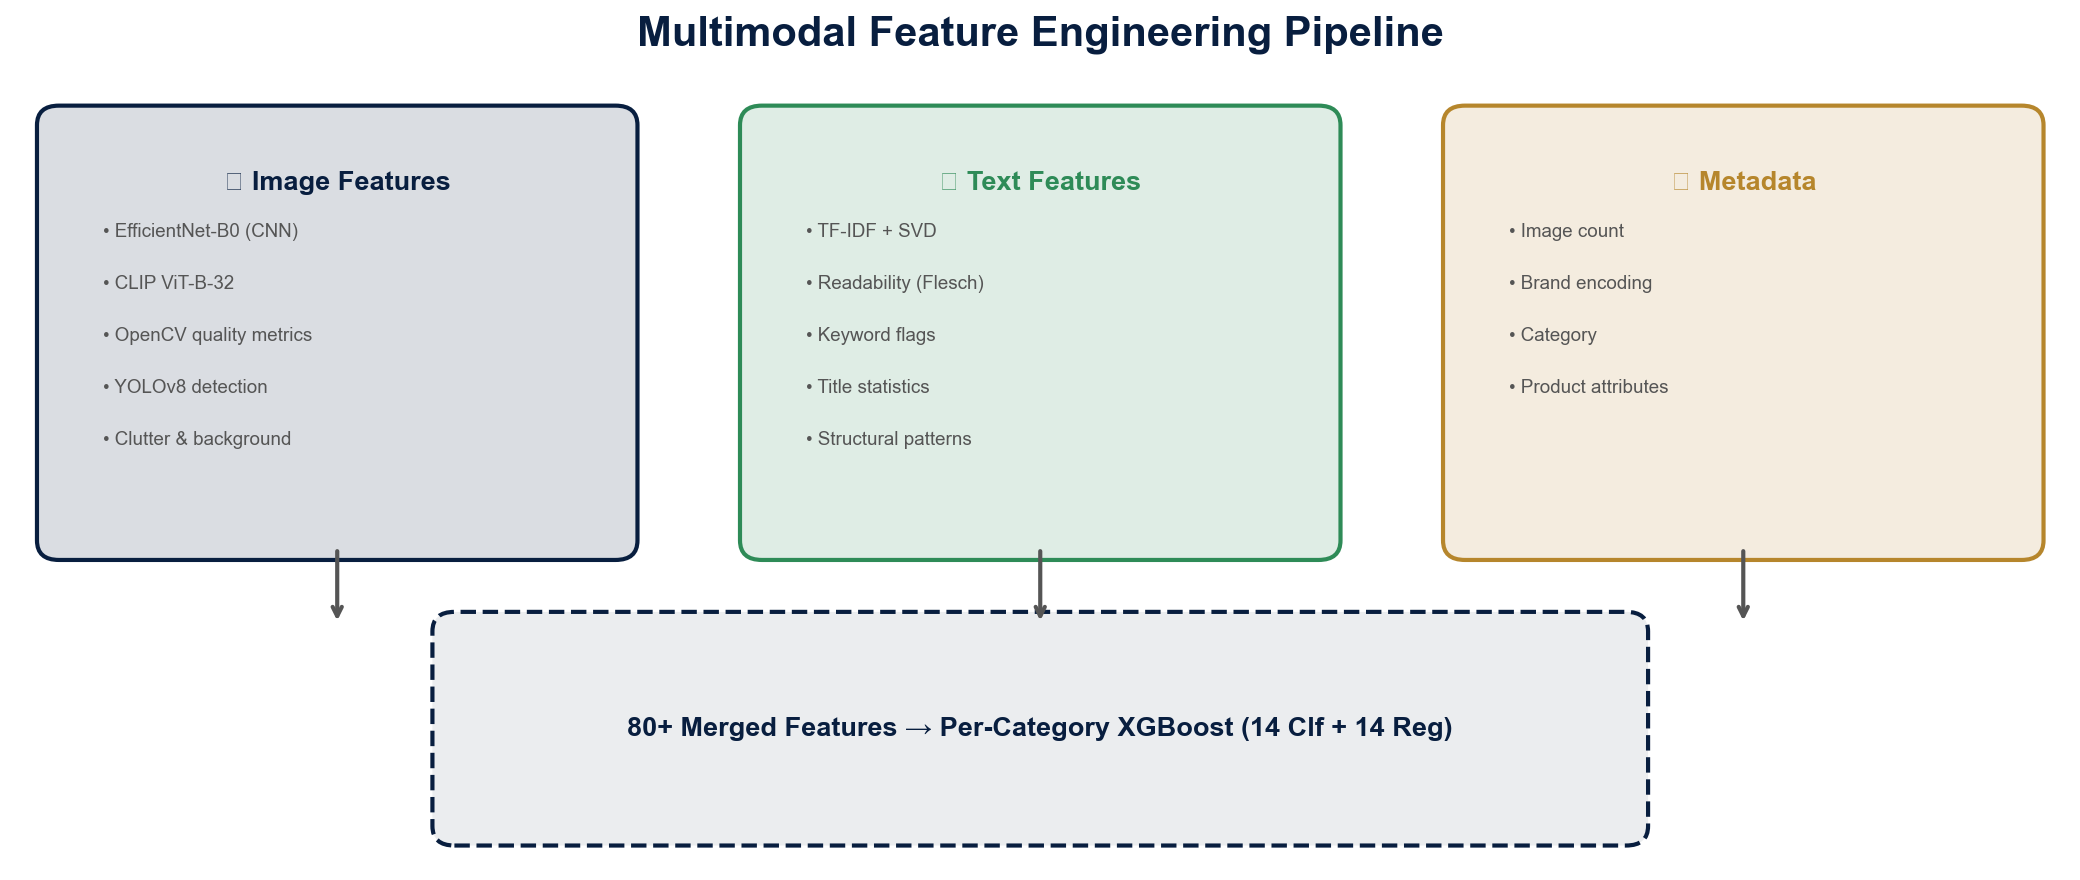

Saved: poster_feature_pipeline.png


In [23]:
# ============================================================
# POSTER FIGURE: Feature Engineering — 3 Modalities
# Visual diagram of the multimodal feature pipeline
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

def draw_box(ax, x, y, w, h, text, color, fontsize=11, sub_items=None):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                         facecolor=color, edgecolor="none", alpha=0.15)
    ax.add_patch(box)
    border = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                            facecolor="none", edgecolor=color, linewidth=2)
    ax.add_patch(border)
    # Title at top of box
    ax.text(x + w/2, y + h - 0.35, text, ha="center", va="top",
            fontsize=fontsize, fontweight="bold", color=color)
    if sub_items:
        for i, item in enumerate(sub_items):
            ax.text(x + 0.3, y + h - 0.75 - i*0.4, f"• {item}",
                    ha="left", va="top", fontsize=9, color=TEXT_MED)

# Image box
draw_box(ax, 0.3, 2.5, 3.8, 3.2, "📷 Image Features", FIU_BLUE, 13,
         ["EfficientNet-B0 (CNN)", "CLIP ViT-B-32", "OpenCV quality metrics",
          "YOLOv8 detection", "Clutter & background"])

# NLP box
draw_box(ax, 5.1, 2.5, 3.8, 3.2, "📝 Text Features", ACCENT_GREEN, 13,
         ["TF-IDF + SVD", "Readability (Flesch)", "Keyword flags",
          "Title statistics", "Structural patterns"])

# Metadata box
draw_box(ax, 9.9, 2.5, 3.8, 3.2, "📊 Metadata", FIU_GOLD, 13,
         ["Image count", "Brand encoding", "Category", "Product attributes"])

# Merge arrow area
merge_box = FancyBboxPatch((3, 0.3), 8, 1.5, boxstyle="round,pad=0.15",
                           facecolor=FIU_BLUE, edgecolor="none", alpha=0.08)
ax.add_patch(merge_box)
merge_border = FancyBboxPatch((3, 0.3), 8, 1.5, boxstyle="round,pad=0.15",
                              facecolor="none", edgecolor=FIU_BLUE, linewidth=2, linestyle="--")
ax.add_patch(merge_border)
ax.text(7, 1.05, "80+ Merged Features → Per-Category XGBoost (14 Clf + 14 Reg)",
        ha="center", va="center", fontsize=13, fontweight="bold", color=FIU_BLUE)

# Arrows from each box down to merge
for x_pos in [2.2, 7.0, 11.8]:
    ax.annotate("", xy=(x_pos, 1.85), xytext=(x_pos, 2.45),
                arrowprops=dict(arrowstyle="->", color=TEXT_MED, lw=2))

plt.title("Multimodal Feature Engineering Pipeline", fontsize=20, fontweight="bold", color=FIU_BLUE, pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_feature_pipeline.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_feature_pipeline.png")


---
# POSTER FIGURE: Two-Stage Model Pipeline
---

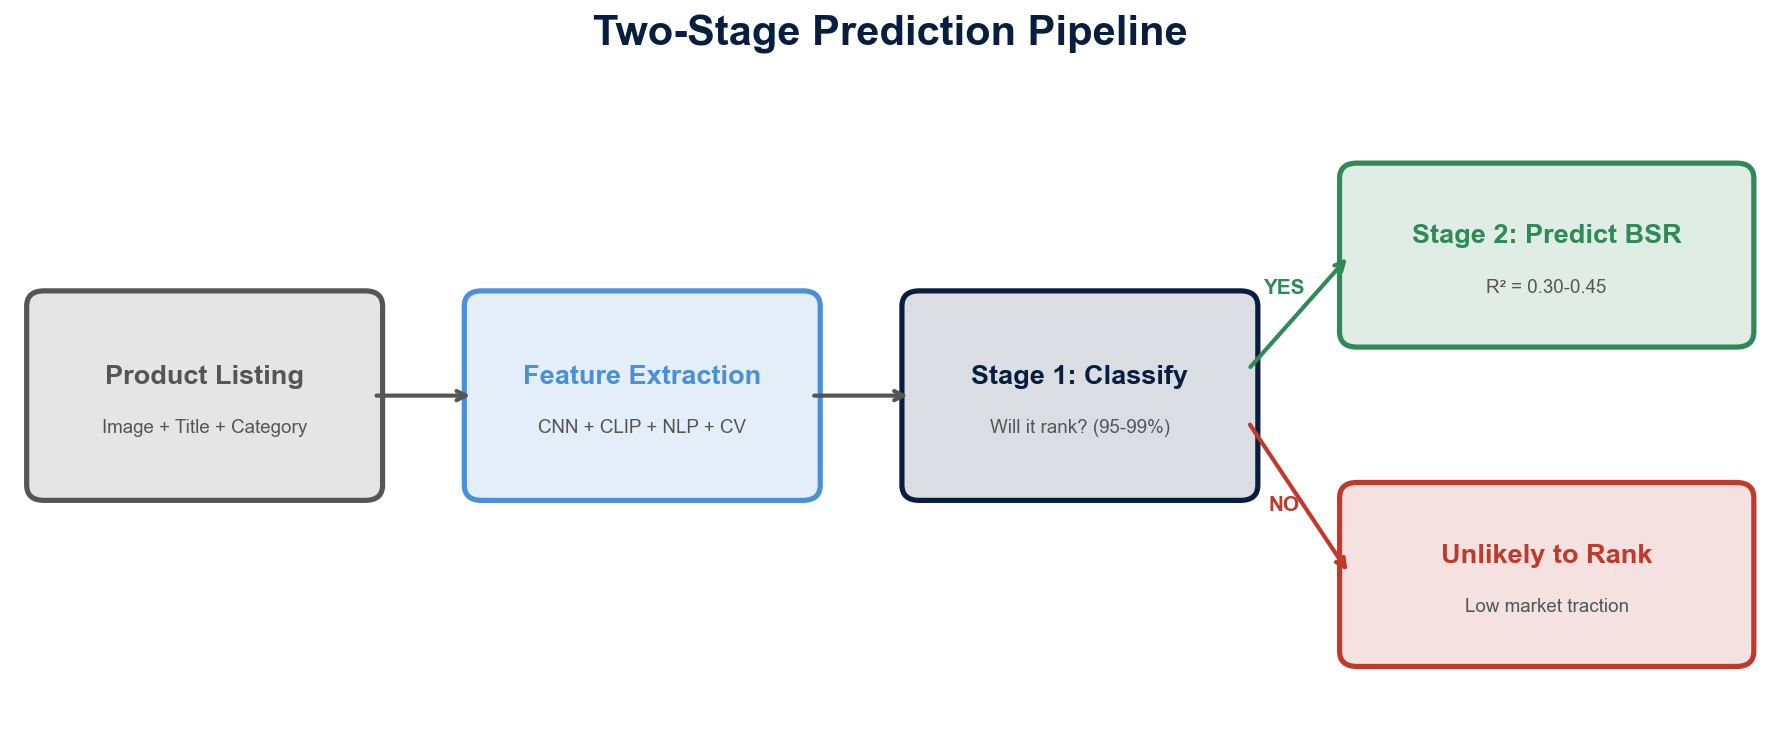

Saved: poster_pipeline.png


In [24]:
# ============================================================
# POSTER FIGURE: Two-Stage Model Pipeline
# ============================================================

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

def make_box(ax, x, y, w, h, title, subtitle, color):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.12",
                         facecolor=color, edgecolor="none", alpha=0.15)
    ax.add_patch(box)
    border = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.12",
                            facecolor="none", edgecolor=color, linewidth=2.5)
    ax.add_patch(border)
    ax.text(x + w/2, y + h/2 + 0.15, title, ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
    ax.text(x + w/2, y + h/2 - 0.25, subtitle, ha="center", va="center",
            fontsize=9, color=TEXT_MED)

# Input
make_box(ax, 0.2, 1.8, 2.2, 1.4, "Product Listing", "Image + Title + Category", TEXT_MED)

# Feature extraction
make_box(ax, 3.2, 1.8, 2.2, 1.4, "Feature Extraction", "CNN + CLIP + NLP + CV", FIU_LIGHT_BLUE)

# Stage 1
make_box(ax, 6.2, 1.8, 2.2, 1.4, "Stage 1: Classify", "Will it rank? (95-99%)", FIU_BLUE)

# Stage 2 (Yes path)
make_box(ax, 9.2, 3.0, 2.6, 1.2, "Stage 2: Predict BSR", "R² = 0.30-0.45", ACCENT_GREEN)

# No path
make_box(ax, 9.2, 0.5, 2.6, 1.2, "Unlikely to Rank", "Low market traction", ACCENT_RED)

# Arrows
arrow_kw = dict(arrowstyle="->", color=TEXT_MED, lw=2)
ax.annotate("", xy=(3.15, 2.5), xytext=(2.45, 2.5), arrowprops=arrow_kw)
ax.annotate("", xy=(6.15, 2.5), xytext=(5.45, 2.5), arrowprops=arrow_kw)

# Yes/No split arrows
ax.annotate("", xy=(9.15, 3.6), xytext=(8.45, 2.7), arrowprops=dict(arrowstyle="->", color=ACCENT_GREEN, lw=2))
ax.annotate("", xy=(9.15, 1.1), xytext=(8.45, 2.3), arrowprops=dict(arrowstyle="->", color=ACCENT_RED, lw=2))

# Yes/No labels
ax.text(8.7, 3.3, "YES", fontsize=10, fontweight="bold", color=ACCENT_GREEN, ha="center")
ax.text(8.7, 1.6, "NO", fontsize=10, fontweight="bold", color=ACCENT_RED, ha="center")

plt.title("Two-Stage Prediction Pipeline", fontsize=20, fontweight="bold", color=FIU_BLUE, pad=15)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_pipeline.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_pipeline.png")


---
# POSTER FIGURE: Key Findings Callout
---

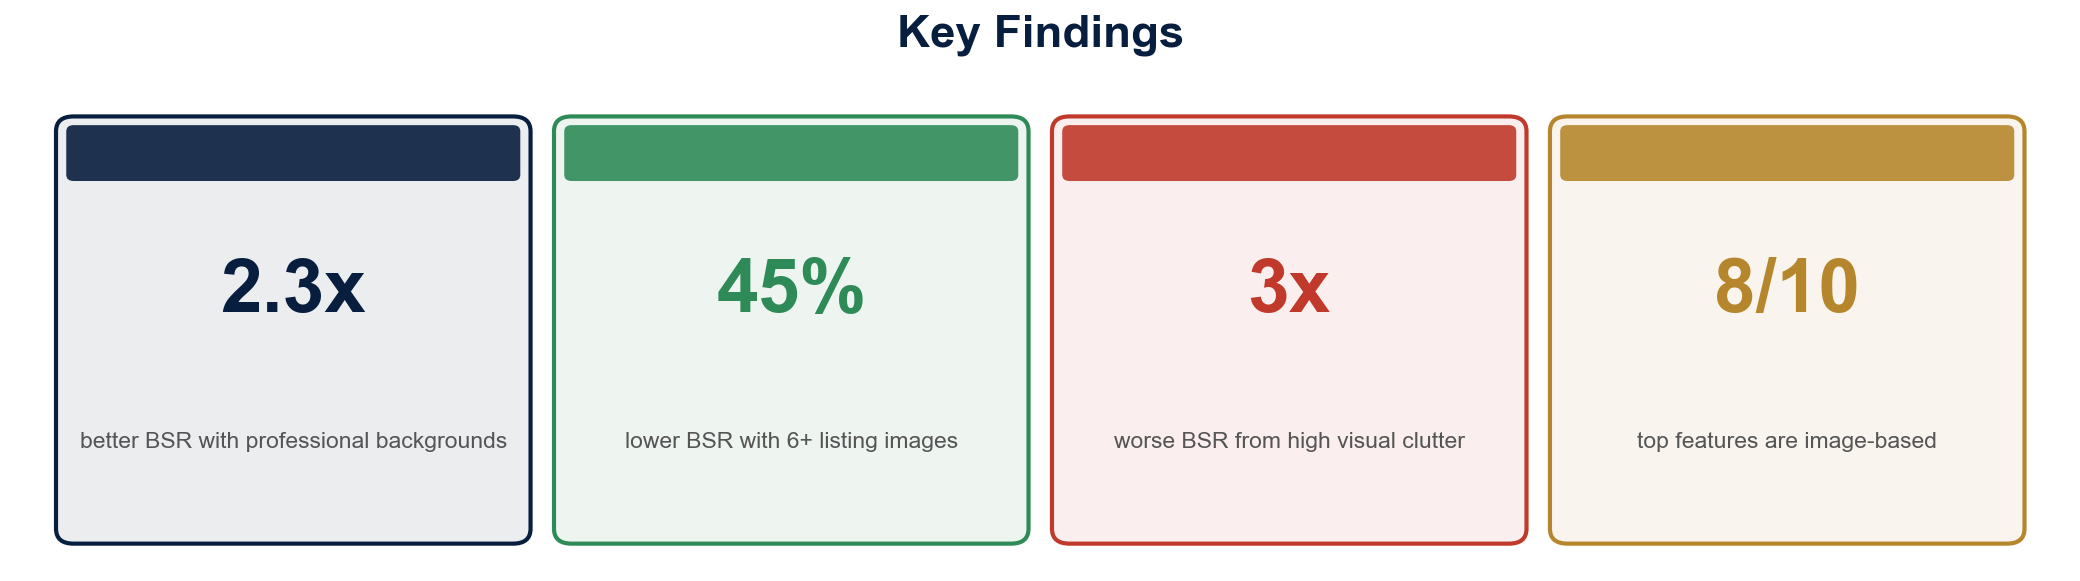

Saved: poster_key_findings.png


In [26]:
# ============================================================
# POSTER FIGURE: Key Findings — Visual callout cards
# ============================================================

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

findings = [
    ("2.3x", "better BSR with professional backgrounds", FIU_BLUE), ("45%", "lower BSR with 6+ listing images", ACCENT_GREEN), ("3x", "worse BSR from high visual clutter", ACCENT_RED), ("8/10", "top features are image-based", FIU_GOLD),
]

card_w = 3.0
gap = 0.4
start_x = (14 - (4 * card_w + 3 * gap)) / 2

for i, (big_num, desc, color) in enumerate(findings):
    x = start_x + i * (card_w + gap)
    # Card
    card = FancyBboxPatch((x, 0.3), card_w, 3.2, boxstyle="round,pad=0.12",
                          facecolor=color, edgecolor="none", alpha=0.08)
    ax.add_patch(card)
    border = FancyBboxPatch((x, 0.3), card_w, 3.2, boxstyle="round,pad=0.12",
                            facecolor="none", edgecolor=color, linewidth=2)
    ax.add_patch(border)
    # Top accent bar
    bar = FancyBboxPatch((x, 3.15), card_w, 0.35, boxstyle="round,pad=0.05",
                         facecolor=color, edgecolor="none", alpha=0.9)
    ax.add_patch(bar)
    # Big number
    ax.text(x + card_w/2, 2.2, big_num, ha="center", va="center",
            fontsize=36, fontweight="bold", color=color)
    # Description
    ax.text(x + card_w/2, 1.0, desc, ha="center", va="center",
            fontsize=11, color=TEXT_MED, linespacing=1.5)

plt.title("Key Findings", fontsize=22, fontweight="bold", color=FIU_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/poster_key_findings.png", dpi=POSTER_DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: poster_key_findings.png")


---
# POSTER: Problem Statement Graphic
---

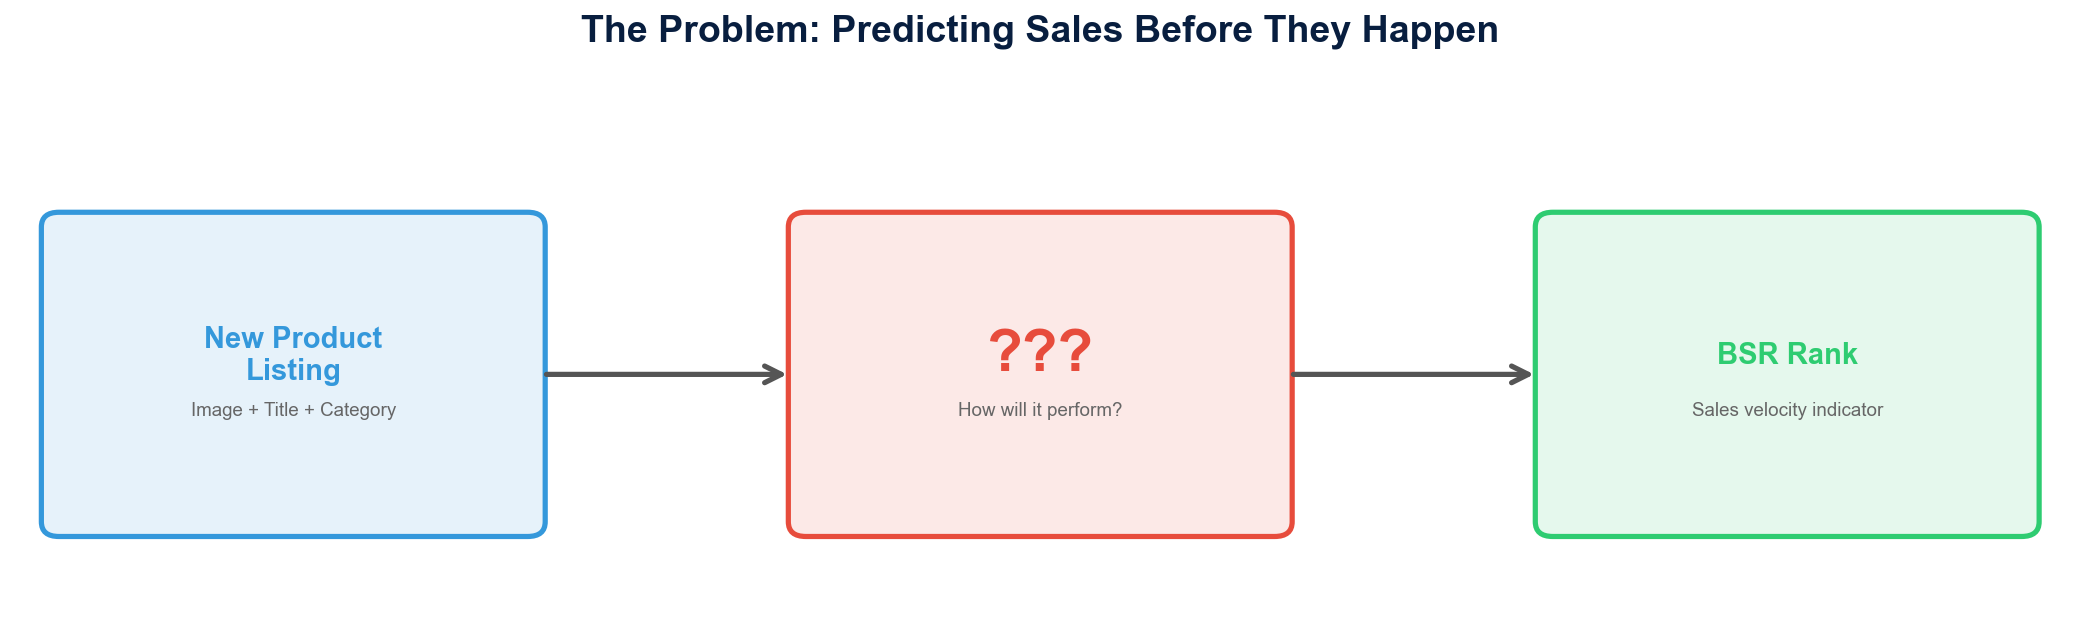

Saved: poster_problem_flow.png


In [27]:
# ============================================================
# POSTER: Problem Flow — New Listing → ??? → BSR Rank
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

# Box helper
def pbox(ax, x, y, w, h, title, sub, color, title_size=14):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                         facecolor=color, edgecolor='none', alpha=0.12)
    ax.add_patch(box)
    border = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                            facecolor='none', edgecolor=color, linewidth=2.5)
    ax.add_patch(border)
    ax.text(x+w/2, y+h/2+0.15, title, ha='center', va='center',
            fontsize=title_size, fontweight='bold', color=color)
    ax.text(x+w/2, y+h/2-0.3, sub, ha='center', va='center',
            fontsize=9, color='#666')

# Three boxes
pbox(ax, 0.3, 0.8, 3.2, 2.4, 'New Product\nListing', 'Image + Title + Category', '#3498DB')
pbox(ax, 5.4, 0.8, 3.2, 2.4, '???', 'How will it perform?', '#E74C3C', title_size=28)
pbox(ax, 10.5, 0.8, 3.2, 2.4, 'BSR Rank', 'Sales velocity indicator', '#2ECC71')

# Arrows
arrow_kw = dict(arrowstyle='->', color='#555', lw=2.5, mutation_scale=20)
ax.annotate('', xy=(5.3, 2.0), xytext=(3.6, 2.0), arrowprops=arrow_kw)
ax.annotate('', xy=(10.4, 2.0), xytext=(8.7, 2.0), arrowprops=arrow_kw)

plt.suptitle('The Problem: Predicting Sales Before They Happen',
             fontsize=18, fontweight='bold', color=FIU_BLUE, y=1.05)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/poster_problem_flow.png', dpi=POSTER_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: poster_problem_flow.png')


---
# POSTER: Solution Flow — Our Approach
---

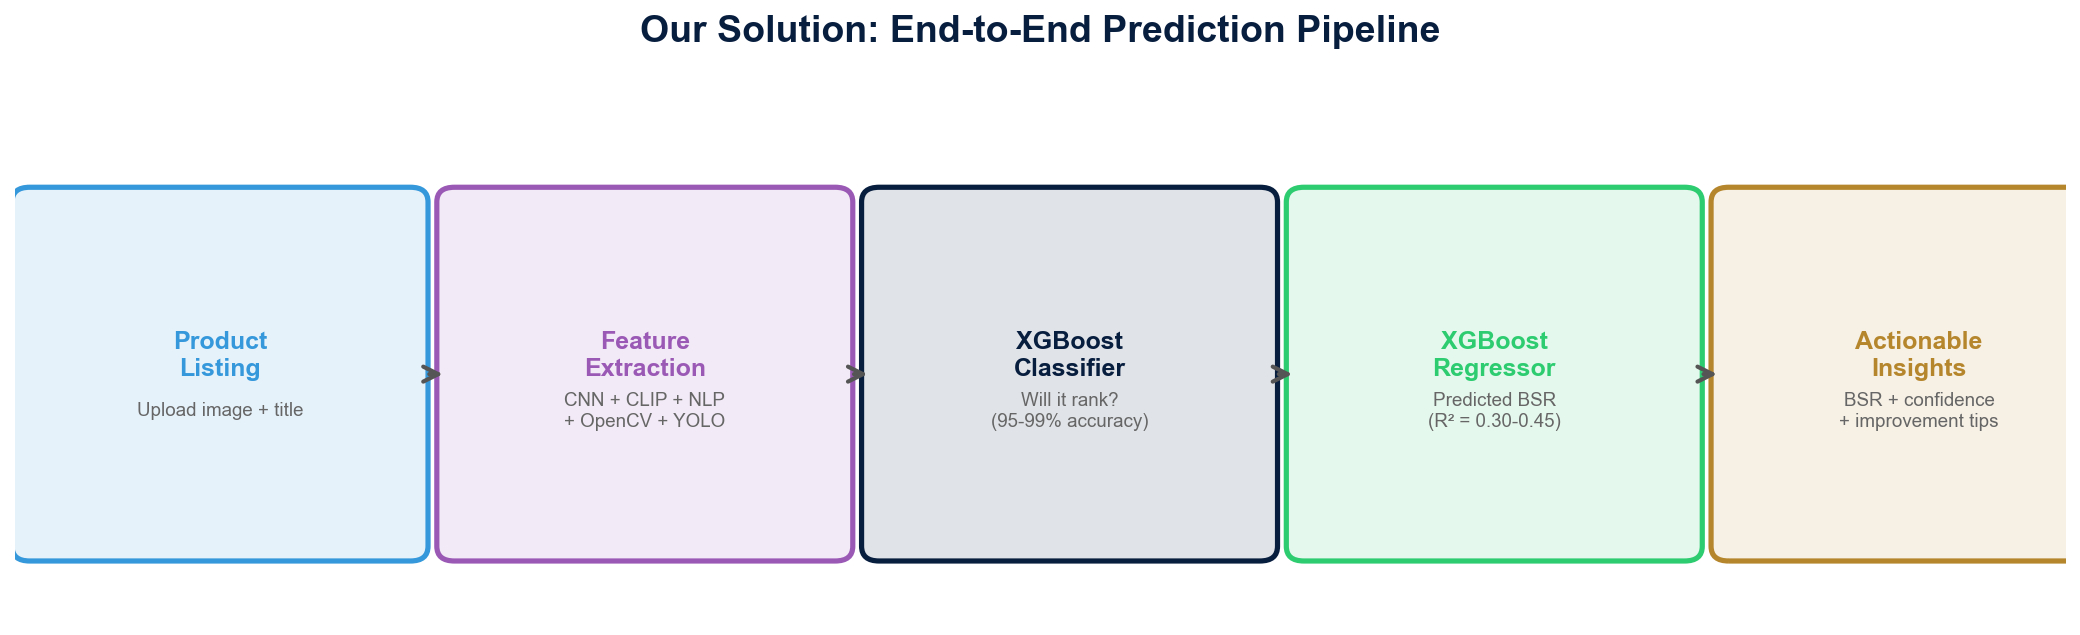

Saved: poster_solution_flow.png


In [28]:
# ============================================================
# POSTER: Solution Flow — What our system does
# ============================================================

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.1, 'Product\nListing', 'Upload image + title', '#3498DB'),
    (3.0, 'Feature\nExtraction', 'CNN + CLIP + NLP\n+ OpenCV + YOLO', '#9B59B6'),
    (5.9, 'XGBoost\nClassifier', 'Will it rank?\n(95-99% accuracy)', FIU_BLUE),
    (8.8, 'XGBoost\nRegressor', 'Predicted BSR\n(R\u00b2 = 0.30-0.45)', '#2ECC71'),
    (11.7, 'Actionable\nInsights', 'BSR + confidence\n+ improvement tips', FIU_GOLD),
]

for x, title, sub, color in boxes:
    pbox(ax, x, 0.6, 2.6, 2.8, title, sub, color, title_size=12)

# Arrows between boxes
arrow_kw = dict(arrowstyle='->', color='#555', lw=2, mutation_scale=18)
for i in range(len(boxes)-1):
    x_from = boxes[i][0] + 2.7
    x_to = boxes[i+1][0] - 0.05
    ax.annotate('', xy=(x_to, 2.0), xytext=(x_from, 2.0), arrowprops=arrow_kw)

plt.suptitle('Our Solution: End-to-End Prediction Pipeline',
             fontsize=18, fontweight='bold', color=FIU_BLUE, y=1.05)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/poster_solution_flow.png', dpi=POSTER_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: poster_solution_flow.png')


---
# POSTER: Data Collection Summary Graphic
---

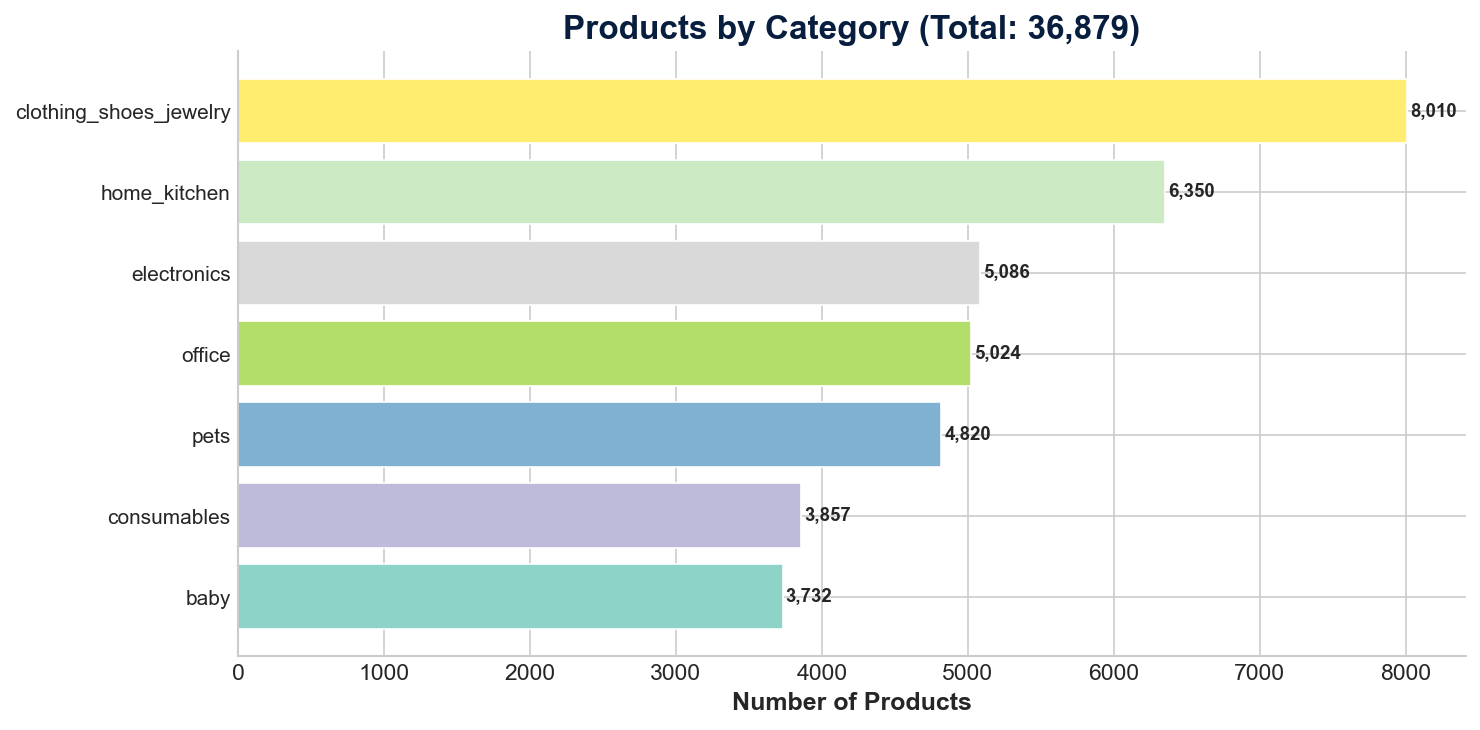

Saved: poster_category_breakdown.png


In [29]:
# ============================================================
# POSTER: Data Collection — category breakdown bar chart
# ============================================================

cat_counts = df['category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(cat_counts)*0.45)))
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
bars = ax.barh(range(len(cat_counts)), cat_counts.values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_yticks(range(len(cat_counts)))
ax.set_yticklabels(cat_counts.index, fontsize=10)
ax.set_xlabel('Number of Products', fontsize=12, fontweight='bold')

# Add count labels
for i, (count, bar) in enumerate(zip(cat_counts.values, bars)):
    ax.text(count + 20, i, f'{count:,}', va='center', fontsize=9, fontweight='bold')

ax.set_title(f'Products by Category (Total: {len(df):,})', fontsize=16, fontweight='bold', color=FIU_BLUE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/poster_category_breakdown.png', dpi=POSTER_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: poster_category_breakdown.png')


---
# POSTER: Web App Architecture Diagram
---

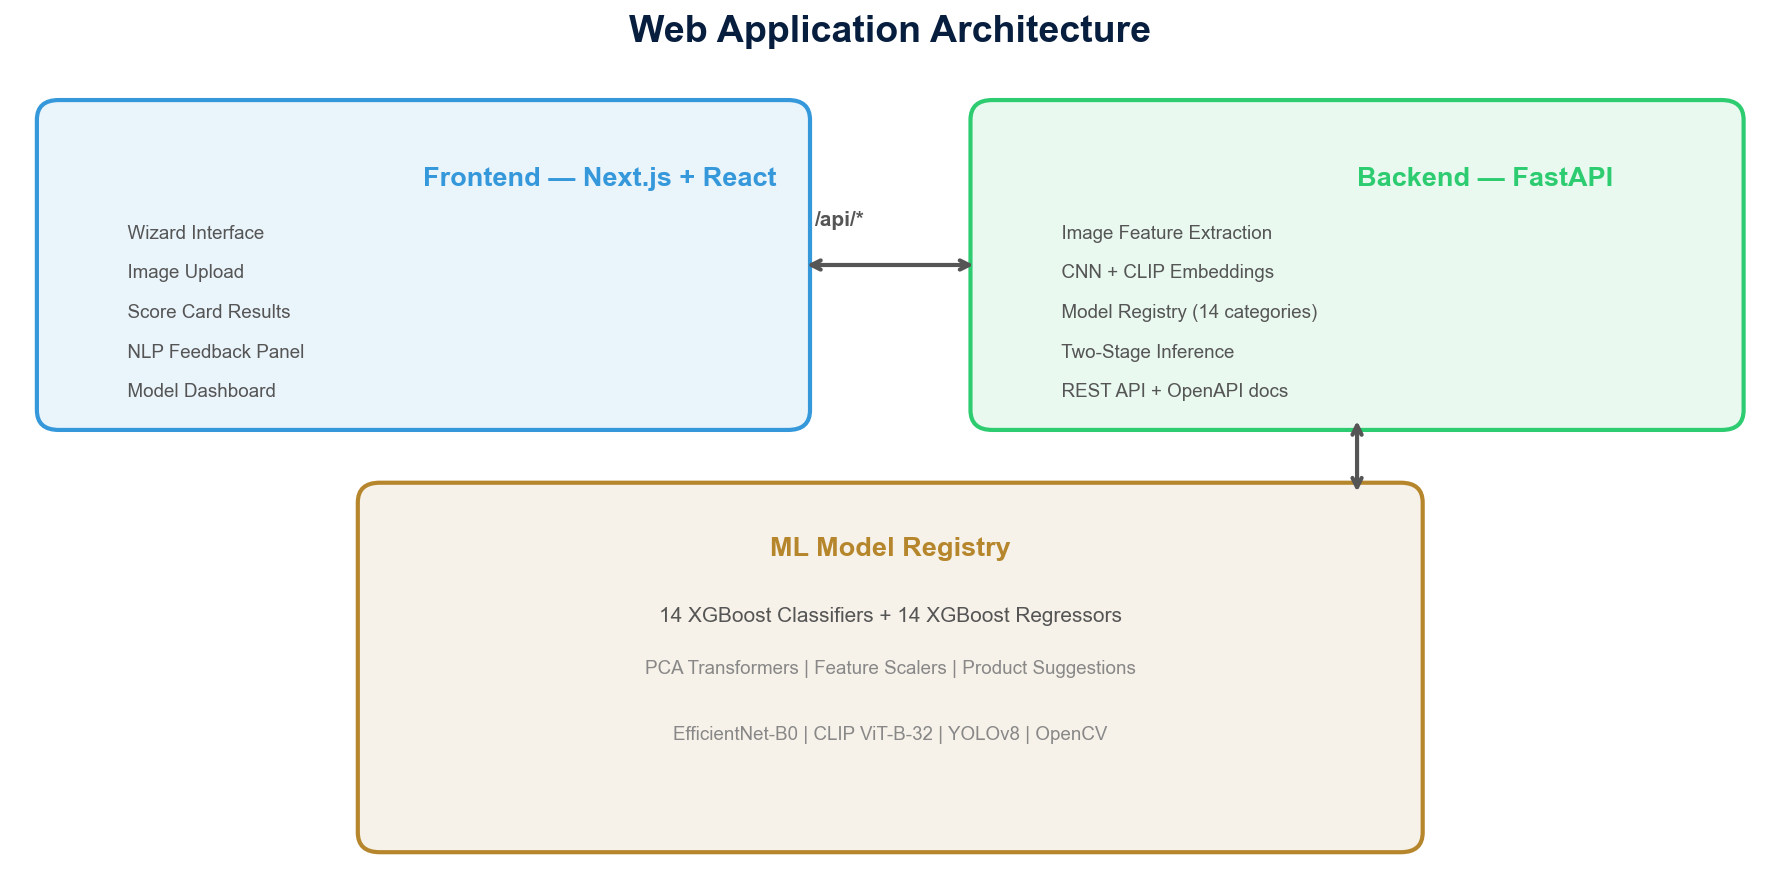

Saved: poster_webapp_arch.png


In [30]:
# ============================================================
# POSTER: Web App Architecture
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

# Frontend box
fe = FancyBboxPatch((0.3, 3.5), 5.0, 2.2, boxstyle='round,pad=0.15',
                     facecolor='#3498DB', edgecolor='none', alpha=0.1)
ax.add_patch(fe)
fe_b = FancyBboxPatch((0.3, 3.5), 5.0, 2.2, boxstyle='round,pad=0.15',
                      facecolor='none', edgecolor='#3498DB', linewidth=2)
ax.add_patch(fe_b)
ax.text(2.8, 5.2, 'Frontend — Next.js + React', fontsize=13, fontweight='bold', color='#3498DB')
fe_items = ['Wizard Interface', 'Image Upload', 'Score Card Results',
            'NLP Feedback Panel', 'Model Dashboard']
for i, item in enumerate(fe_items):
    ax.text(0.7, 4.8-i*0.3, f'  {item}', fontsize=9, color='#555')

# Backend box
be = FancyBboxPatch((6.7, 3.5), 5.0, 2.2, boxstyle='round,pad=0.15',
                     facecolor='#2ECC71', edgecolor='none', alpha=0.1)
ax.add_patch(be)
be_b = FancyBboxPatch((6.7, 3.5), 5.0, 2.2, boxstyle='round,pad=0.15',
                      facecolor='none', edgecolor='#2ECC71', linewidth=2)
ax.add_patch(be_b)
ax.text(9.2, 5.2, 'Backend — FastAPI', fontsize=13, fontweight='bold', color='#2ECC71')
be_items = ['Image Feature Extraction', 'CNN + CLIP Embeddings', 'Model Registry (14 categories)',
            'Two-Stage Inference', 'REST API + OpenAPI docs']
for i, item in enumerate(be_items):
    ax.text(7.1, 4.8-i*0.3, f'  {item}', fontsize=9, color='#555')

# Arrow between frontend and backend
ax.annotate('', xy=(6.6, 4.6), xytext=(5.4, 4.6),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=2))
ax.text(5.65, 4.9, '/api/*', fontsize=10, fontweight='bold', color='#555', ha='center')

# ML Models box at bottom
ml = FancyBboxPatch((2.5, 0.3), 7.0, 2.5, boxstyle='round,pad=0.15',
                     facecolor=FIU_GOLD, edgecolor='none', alpha=0.1)
ax.add_patch(ml)
ml_b = FancyBboxPatch((2.5, 0.3), 7.0, 2.5, boxstyle='round,pad=0.15',
                      facecolor='none', edgecolor=FIU_GOLD, linewidth=2)
ax.add_patch(ml_b)
ax.text(6.0, 2.4, 'ML Model Registry', fontsize=13, fontweight='bold', color=FIU_GOLD, ha='center')
ax.text(6.0, 1.9, '14 XGBoost Classifiers + 14 XGBoost Regressors', fontsize=10, color='#555', ha='center')
ax.text(6.0, 1.5, 'PCA Transformers | Feature Scalers | Product Suggestions', fontsize=9, color='#888', ha='center')
ax.text(6.0, 1.0, 'EfficientNet-B0 | CLIP ViT-B-32 | YOLOv8 | OpenCV', fontsize=9, color='#888', ha='center')

# Arrow from backend down to models
ax.annotate('', xy=(9.2, 2.85), xytext=(9.2, 3.45),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=2))

plt.suptitle('Web Application Architecture', fontsize=18, fontweight='bold', color=FIU_BLUE, y=0.98)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/poster_webapp_arch.png', dpi=POSTER_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: poster_webapp_arch.png')


---
# ✅ POSTER FIGURES COMPLETE
---

In [31]:
import os
print("" + "="*70)
print("✅ ALL POSTER FIGURES GENERATED!")
print("="*70)
print(f"Saved to: {os.path.abspath(SAVE_DIR)}/")
print("Files:")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith(".png"):
        size_kb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
        print(f"  ✓ {f} ({size_kb:.0f} KB)")
print("Drag these into your poster tool (PowerPoint, Canva, Google Slides).")
print("All images are 300 DPI with white backgrounds.")


✅ ALL POSTER FIGURES GENERATED!
Saved to: /Users/dsuniaga/Desktop/cis_amazon_forecast_proj/notebooks/04-Final Modeling/poster_figures/
Files:
  ✓ poster_category_breakdown.png (128 KB)
  ✓ poster_feature_pipeline.png (238 KB)
  ✓ poster_key_findings.png (151 KB)
  ✓ poster_metric_cards.png (135 KB)
  ✓ poster_pipeline.png (170 KB)
  ✓ poster_problem_flow.png (116 KB)
  ✓ poster_solution_flow.png (177 KB)
  ✓ poster_table_data.png (158 KB)
  ✓ poster_table_results.png (231 KB)
  ✓ poster_table_techstack.png (209 KB)
  ✓ poster_webapp_arch.png (243 KB)
Drag these into your poster tool (PowerPoint, Canva, Google Slides).
All images are 300 DPI with white backgrounds.


---
# ALL FIGURES GENERATED
---

In [ ]:
print('='*70)
print('ALL REPORT + POSTER FIGURES GENERATED')
print('='*70)
print()
print('Report Figures:')
print('  Figure 1:  Clutter Score Comparison')
print('  Figure 2:  Feature Correlation Heatmap')
print('  Figure 3:  BSR Distribution (Raw vs Log)')
print('  Figure 4:  BSR by Image Count')
print('  Figure 5:  Confusion Matrix')
print('  Figure 6:  Actual vs Predicted log(BSR)')
print('  Figure 7:  Feature Importance by Category')
print('  Figure 8:  ROC Curve')
print('  Figure 9:  Residuals Distribution')
print('  Figure 10: Cross-Validation Stability')
print('  Figure 11: Per-Category Performance')
print('  Figure 12: Prediction Cards')
print()
print('Poster Figures (in poster_figures/):')
print('  Data at a Glance table')
print('  Results Comparison (C1 vs C2)')
print('  Tech Stack table')
print('  Metric highlight cards')
print('  Feature pipeline diagram')
print('  Two-stage pipeline diagram')
print('  Key findings callout cards')
